# E10 · Signal in the noise: a Bayesian look at GW150914

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real LIGO strain from Hanford (H1) and Livingston (L1): 32 s at 4096 Hz around GW150914, the first detected binary-black-hole merger (Gravitational Wave Open Science Center) |
| **You will learn** | Whitening and coloured-noise likelihoods · a time-domain Gaussian likelihood with a full noise covariance · quadrature (linear) amplitude parameters instead of a wrapped phase · pushing a posterior through a physics formula (ringdown → black-hole mass and spin) · analytic marginalisation of linear parameters · Bayes factors that actually compute (grid, SMC) and a background distribution · simulation-based calibration on real noise · matched filtering · an instructive sampler failure and a model-systematics lesson on the inspiral chirp |

On 14 September 2015 the two LIGO detectors recorded a 0.2 s "chirp" from two black holes
merging 1.3 billion light years away. The strain data are public. This notebook asks what
a Bayesian practitioner with **NumPy, SciPy and PyMC only** can learn from them.

**What this notebook is, and is not.** It is a simplified, pedagogical analysis: analytic
toy waveforms (a damped sinusoid, a leading-order chirp), a noise model estimated from
30 s of data, no detector calibration uncertainty, no sky location or polarisation model.
It is **not** a reproduction of the LIGO-Virgo analysis, which uses numerical-relativity
calibrated waveforms with 15 parameters and specialised samplers. Where our numbers
agree with the published ones we will say "consistent with", not "confirms"; where they
differ we will say so and look for the reason.

The plan:

1. **See the signal** - spectral estimation, whitening, band-passing, a time-frequency map.
2. **Fit the ringdown** - the one piece of the waveform with a closed-form model - jointly
   in both detectors, and turn its frequency and damping time into a **mass and spin**.
3. **Is there really a signal?** - off-source fits, a Bayes factor with a background
   distribution, calibration checks, and the classical matched filter.
4. **The inspiral chirp** (stretch) - a sampler failure, its fix, and a bias the posterior
   cannot warn you about.

In [1]:
import arviz as az
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy import linalg, signal, stats
from scipy.special import logsumexp

from pymc_challenges import data

RANDOM_SEED = 150914
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## Part 1 · Seeing the signal

### 1.1 · The data

The files are HDF5, straight from GWOSC, so we open them with `h5py` rather than
`data.load`. Strain is dimensionless (relative arm-length change) and absurdly small, so
**everything below is in units of $10^{-21}$**. Times are seconds relative to GPS
1126259462.4, the nominal event time, about 15.4 s into the segment.

In [2]:
GPS_EVENT = 1126259462.4
DETECTORS = ["H1", "L1"]

strain = {}
for det in DETECTORS:
    name = f"gw150914_{det.lower()}"
    data.describe(name)
    with h5py.File(data.path(name)) as f:
        dset = f["strain/Strain"]
        strain[det] = dset[:] * 1e21
        dt = float(dset.attrs["Xspacing"])
        gps_start = int(f["meta/GPSstart"][()])

fs = 1 / dt
n_samples = len(strain["H1"])
t = (gps_start - GPS_EVENT) + np.arange(n_samples) * dt
print(f"\n{n_samples} samples per detector at {fs:.0f} Hz, t from {t[0]:.2f} s to {t[-1]:.2f} s")
print({det: f"rms = {x.std():.0f} x 1e-21" for det, x in strain.items()})

gw150914_h1: 32 s of LIGO Hanford strain at 4096 Hz around GW150914 (GPS 1126259462.4). HDF5: use data.path().
  source: LIGO Scientific Collaboration / Gravitational Wave Open Science Center (gwosc.org).
  url:    https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5
gw150914_l1: 32 s of LIGO Livingston strain at 4096 Hz around GW150914 (GPS 1126259462.4). HDF5: use data.path().
  source: LIGO Scientific Collaboration / Gravitational Wave Open Science Center (gwosc.org).
  url:    https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5

131072 samples per detector at 4096 Hz, t from -15.40 s to 16.60 s
{'H1': 'rms = 218 x 1e-21', 'L1': 'rms = 231 x 1e-21'}


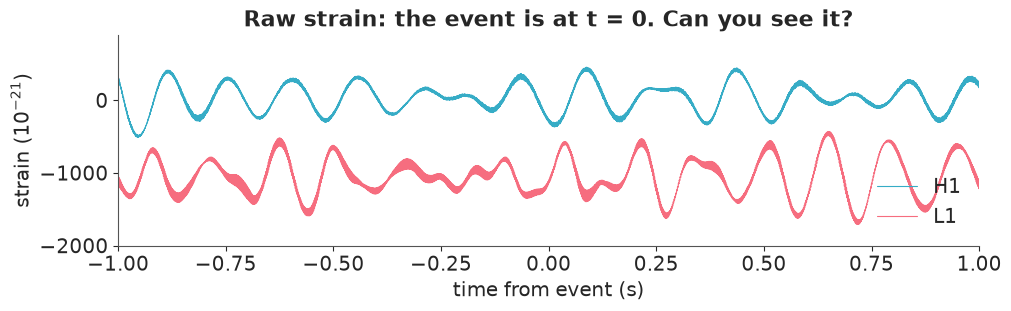

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
for det in DETECTORS:
    ax.plot(t, strain[det], lw=0.8, label=det)
ax.set(xlim=(-1, 1), xlabel="time from event (s)", ylabel="strain ($10^{-21}$)",
       title="Raw strain: the event is at t = 0. Can you see it?")
ax.legend();

Nothing to see. The raw strain wanders by a few hundred units (L1 also carries a constant
offset of about -1000), while the signal we are after peaks at about **one** unit. The wandering is low-frequency noise (seismic motion,
suspension resonances); the detector is only quiet in a band from a few tens to a few
hundred hertz. To see anything we must weight each frequency by how noisy it is.

### 1.2 · The noise spectrum

The **power spectral density** (PSD) $S(f)$ says how much noise variance there is per
hertz. Welch's method estimates it by averaging periodograms of overlapping windowed
chunks. We use only **off-source** data, more than 2 s away from the event, so the signal
cannot leak into its own noise estimate.

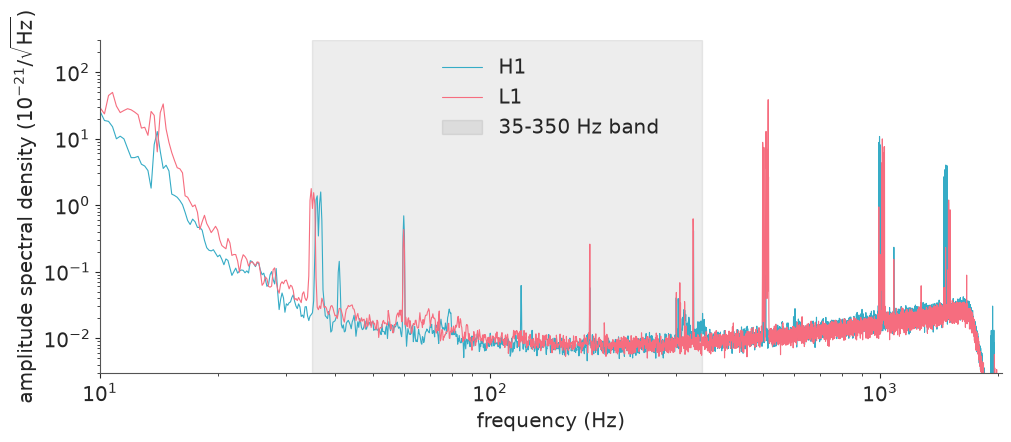

In [4]:
def offsource_psd(x, times, seconds, guard=2.0):
    """One-sided Welch PSD from data more than `guard` s away from the event (both sides averaged)."""
    rate = 1 / (times[1] - times[0])
    psds, weights = [], []
    for mask in (times < -guard, times > guard):
        freqs_w, p = signal.welch(x[mask], fs=rate, nperseg=int(seconds * rate), window="hann")
        psds.append(p)
        weights.append(mask.sum())
    return freqs_w, np.average(psds, axis=0, weights=weights)


psd = {det: offsource_psd(strain[det], t, seconds=4) for det in DETECTORS}

fig, ax = plt.subplots(figsize=(10, 4))
for det in DETECTORS:
    ax.loglog(psd[det][0], np.sqrt(psd[det][1]), lw=0.8, label=det)
ax.axvspan(35, 350, color="k", alpha=0.07, label="35-350 Hz band")
ax.set(xlim=(10, 2048), ylim=(3e-3, 3e2), xlabel="frequency (Hz)",
       ylabel=r"amplitude spectral density ($10^{-21}/\sqrt{\mathrm{Hz}}$)")
ax.legend();

The amplitude spectral density falls by a factor of several thousand - some seven orders
of magnitude in power - between 10 Hz and the quiet "bucket" near 100-300 Hz, and there
is a forest of narrow lines on top (mains harmonics at multiples of 60 Hz, suspension
"violin" modes near 500 Hz and their harmonics near 1 kHz, calibration lines). This is
what **coloured** noise looks like.

### 1.3 · Whitening and band-passing

**Whitening** divides the Fourier transform of the data by $\sqrt{S(f)}$. Every frequency
then carries the same noise power: the loud low frequencies are turned down, the quiet
bucket is turned up. With the normalisation below, stationary Gaussian noise with PSD
$S(f)$ becomes (approximately) unit-variance **white** Gaussian noise. We then band-pass
to 35-350 Hz, where the signal lives, using a zero-phase Butterworth response applied in
the frequency domain.

In [5]:
freqs = np.fft.rfftfreq(n_samples, dt)
taper = signal.windows.tukey(n_samples, 0.1)  # avoids edge ringing in the FFT
sos_bp = signal.butter(4, [35, 350], btype="bandpass", fs=fs, output="sos")
bp_gain = np.abs(signal.sosfreqz(sos_bp, worN=freqs, fs=fs)[1]) ** 2  # zero-phase, like filtfilt

psd_on_grid = {det: np.interp(freqs, *psd[det]) for det in DETECTORS}
white, white_bp = {}, {}
for det in DETECTORS:
    whitening = 1 / np.sqrt(psd_on_grid[det] * fs / 2)  # white noise of unit variance has S = 2/fs
    spectrum = np.fft.rfft(strain[det] * taper)
    white[det] = np.fft.irfft(spectrum * whitening, n=n_samples)
    white_bp[det] = np.fft.irfft(spectrum * whitening * bp_gain, n=n_samples)

quiet = (np.abs(t) > 2) & (np.abs(t) < 13)
for det in DETECTORS:
    print(f"{det}: off-source std  whitened = {white[det][quiet].std():.2f}   "
          f"whitened + band-passed = {white_bp[det][quiet].std():.2f}")

H1: off-source std  whitened = 0.99   whitened + band-passed = 0.37
L1: off-source std  whitened = 1.15   whitened + band-passed = 0.37


Whitened H1 noise has a standard deviation of 0.99, as designed. L1 comes out at 1.15; the
excess sits entirely below 10 Hz (slow drifts that a PSD built from 4 s chunks cannot
resolve) and disappears once we band-pass. After the band-pass both detectors are at
0.37: we kept roughly $(350-35)/2048 \approx 15\%$ of the bandwidth and hence of the
variance ($\sqrt{0.15} = 0.39$). Hold on to that number - it matters in section 2.8.

Now the famous picture. The source was closer to Livingston, and the two detectors are
oriented almost oppositely, so we **cross-correlate** to find the shift and sign that
best overlay L1 on H1.

In [6]:
window = (t > -0.15) & (t < 0.05)
idx = np.flatnonzero(window)
lags = np.arange(-60, 61)  # +-15 ms; the light travel time between the sites is 10 ms
xcorr = np.array([np.sum(white_bp["H1"][idx] * white_bp["L1"][idx - lag]) for lag in lags])
k = np.argmax(np.abs(xcorr))
y0, y1, y2 = np.abs(xcorr[k - 1 : k + 2])
lag_refined = lags[k] + 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2)  # parabolic interpolation of the peak
norm = np.sqrt(np.sum(white_bp["H1"][idx] ** 2) * np.sum(white_bp["L1"][idx - lags[k]] ** 2))

DT_HL = lag_refined * dt  # seconds by which H1 lags L1
SIGN_HL = np.sign(xcorr[k])
print(f"best overlay: shift L1 later by {DT_HL * 1e3:.1f} ms, sign {SIGN_HL:+.0f}, "
      f"correlation {xcorr[k] / norm:.2f}")

best overlay: shift L1 later by 7.3 ms, sign -1, correlation -0.72


H1 whitened envelope peaks at t = 24.3 ms


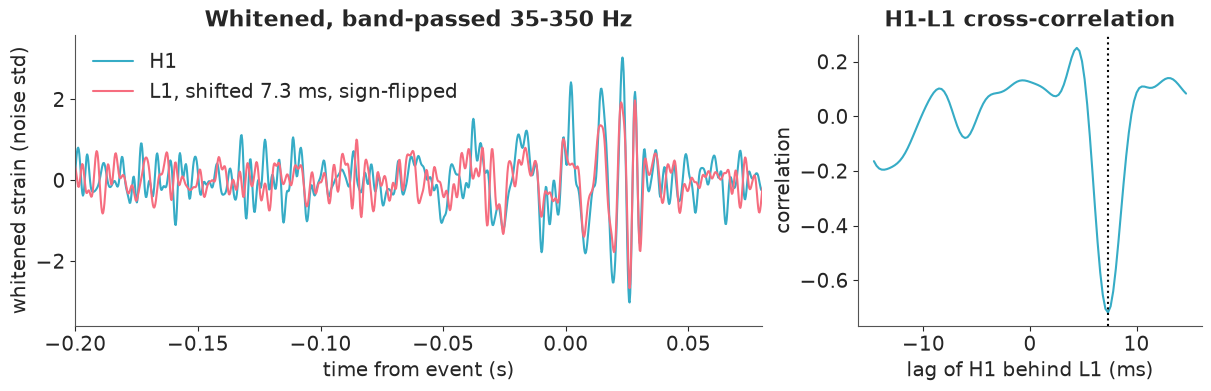

In [7]:
T_PEAK = 0.023  # published time of peak strain at Hanford, relative to GPS_EVENT (see section 2.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), width_ratios=[2, 1])
axes[0].plot(t, white_bp["H1"], label="H1")
axes[0].plot(t + DT_HL, SIGN_HL * white_bp["L1"], label=f"L1, shifted {DT_HL * 1e3:.1f} ms, sign-flipped")
axes[0].set(xlim=(-0.2, 0.08), ylim=(-3.6, 3.6), xlabel="time from event (s)",
            ylabel="whitened strain (noise std)", title="Whitened, band-passed 35-350 Hz")
axes[0].legend(loc="upper left")
axes[1].plot(lags * dt * 1e3, xcorr / norm)
axes[1].axvline(DT_HL * 1e3, color="k", ls=":")
axes[1].set(xlabel="lag of H1 behind L1 (ms)", ylabel="correlation", title="H1-L1 cross-correlation");

envelope = np.abs(signal.hilbert(white_bp["H1"]))
t_env_peak = t[np.argmax(envelope * (np.abs(t) < 0.1))]
print(f"H1 whitened envelope peaks at t = {t_env_peak * 1e3:.1f} ms")

There it is: a handful of cycles growing in amplitude and frequency, a peak, and a rapid
decay - the same shape in two instruments 3000 km apart, with Livingston about 7 ms
ahead and with the opposite sign (a correlation of -0.72 between two independent
detectors). The LIGO papers quote an arrival-time difference of $6.9^{+0.5}_{-0.4}$ ms;
our crude cross-correlation estimate of 7.3 ms is in the same place. It is one number
from one filter choice with no uncertainty attached; we return to the time shift in 2.5.
The correlation has a single clean dip because the chirp is **broadband**: every frequency
agrees on one time shift. Remember that when we get to the narrow-band ringdown.

### 1.4 · A time-frequency map

A short-time Fourier transform has one fixed time resolution. For a chirp it is better
to use windows that get shorter as frequency rises (constant $Q = f/\Delta f$), which is
the idea of the "Q-transform" used in LIGO's own plots. A bare-bones version is a
Gaussian band-pass around each frequency, applied in the Fourier domain:

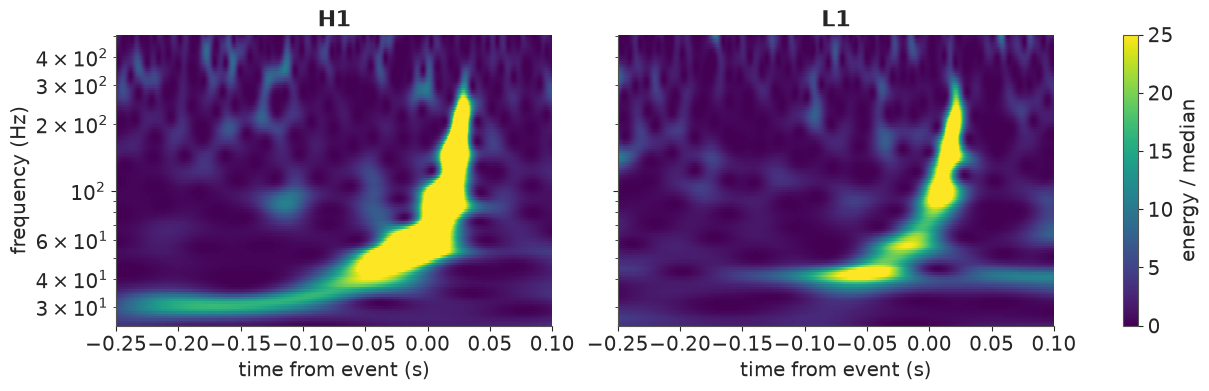

In [8]:
def q_transform(x, rate, centre_freqs, q=8.0):
    """Energy in constant-Q Gaussian frequency bands. Each row is normalised by its median."""
    n = len(x)
    spectrum = np.fft.rfft(x)
    fr = np.fft.rfftfreq(n, 1 / rate)
    out = np.empty((len(centre_freqs), n))
    for i, f0 in enumerate(centre_freqs):
        analytic = np.zeros(n, dtype=complex)
        analytic[: len(fr)] = spectrum * np.exp(-0.5 * ((fr - f0) / (f0 / q)) ** 2)  # positive freqs only
        out[i] = np.abs(np.fft.ifft(analytic)) ** 2
    return out / np.median(out, axis=1, keepdims=True)


chunk = np.abs(t) < 2  # transform 4 s so that filter edge effects stay far from the event ...
view = (t[chunk] > -0.3) & (t[chunk] < 0.15)  # ... but draw only what is shown: 8x fewer quads to hold in memory
q_freqs = np.geomspace(25, 500, 120)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, det in zip(axes, DETECTORS):
    energy = q_transform(white[det][chunk], fs, q_freqs)[:, view]
    mesh = ax.pcolormesh(t[chunk][view], q_freqs, energy, vmin=0, vmax=25, shading="auto", cmap="viridis")
    ax.set(xlim=(-0.25, 0.1), yscale="log", xlabel="time from event (s)", title=det)
    ax.grid(False)
axes[0].set_ylabel("frequency (Hz)")
fig.colorbar(mesh, ax=axes, label="energy / median");

The textbook chirp: the frequency sweeps from about 35 Hz to about 250 Hz in 0.2 s, and
the sweep accelerates. In both detectors. That upward sweep is two masses spiralling
together (Part 4); the abrupt end is the merger; what follows the peak is the newborn
black hole settling down - the **ringdown** (Part 2).

### 1.5 · Why whitening gives a likelihood, and where the shortcut breaks

If the noise is stationary and Gaussian, its Fourier coefficients at different frequencies
are independent with variance proportional to $S(f)$. That is the **Whittle likelihood**:

$$\log p(d \mid \theta) = -\tfrac{1}{2}\sum_k \frac{|\tilde d_k - \tilde h_k(\theta)|^2}{\sigma_k^2} + \text{const},
\qquad \sigma_k^2 \propto S(f_k).$$

Dividing by $\sqrt{S}$ makes every $\sigma_k$ equal, and by Parseval's theorem the sum over
frequencies becomes a sum over time samples: *whitened data minus whitened template is
unit-variance white noise*, i.e. `pm.Normal(mu=whitened_template, sigma=1)`. That is the
attraction. The shortcut has three traps, though:

1. **The template must be whitened too.** The filter changes the shape of any signal. You
   cannot fit an un-whitened damped sinusoid to whitened data.
2. **Band-passed samples are not independent.** After the band-pass the noise has std 0.37
   and neighbouring samples are strongly correlated. If you "helpfully" set or fit
   `sigma = 0.37` with independent samples you count the same information several times.
3. **The filters are acausal and long.** Whitening and zero-phase band-passing smear every
   feature over tens of milliseconds in both directions. For the ringdown we want to use
   data *after* a start time $t_0$ and nothing before it - but the filtered data after
   $t_0$ contain smeared-in power from the much louder merger just before it.

Trap 3 is the reason ringdown analyses in the literature (Isi & Farr 2021, and the
`ringdown` package) work **in the time domain with the full noise covariance matrix**.
That is what we will do. It is exact for stationary Gaussian noise, it handles the
truncation at $t_0$ with no leakage, and it whitens data and template with the same
operator by construction. In section 2.8 we come back and measure what the shortcut
would have cost.

## Part 2 · The ringdown: weighing a black hole with a damped sinusoid

A perturbed black hole rings like a struck bell, in damped sinusoids called quasi-normal
modes. Keeping only the dominant one,

$$h(t) = A\,e^{-(t-t_0)/\tau}\cos\!\big(2\pi f\,(t-t_0) - \varphi\big), \qquad t \ge t_0 .$$

General relativity says $f$ and $\tau$ depend **only on the mass and spin** of the final
black hole, so measuring them weighs the remnant.

### 2.1 · A noise model in the time domain

Stationary Gaussian noise is fully described by its autocovariance function
$\rho(k) = \mathrm{cov}(n_i, n_{i+k})$, the inverse Fourier transform of the PSD. For a
window of $N$ samples the noise is $\mathcal{N}(0, C)$ with $C_{ij} = \rho(|i-j|)$.
With the Cholesky factor $C = LL^\top$,

$$ L^{-1} d \;\sim\; \mathcal{N}\big(L^{-1} h(\theta),\; I\big). $$

$L^{-1}$ is a whitening filter too - the time-domain, finite-window counterpart of dividing
by $\sqrt{S(f)}$ - but it is lower-triangular, hence **causal**: nothing before the window
leaks in, and the template is whitened by the same matrix as the data.

Conditioning, following common practice: high-pass at 20 Hz (below that there is only
noise, and it would wreck the conditioning of $C$), down-sample to 2048 Hz (the ringdown
is at ~250 Hz; the top octave only adds cost and an anti-aliasing roll-off that $C$ would
have to model), then estimate the PSD from off-source data as before.

In [9]:
t_fit = t[::2]
FS_FIT = fs / 2
sos_hp = signal.butter(4, 20, btype="highpass", fs=fs, output="sos")
cond = {det: signal.decimate(signal.sosfiltfilt(sos_hp, strain[det]), 2, ftype="fir", zero_phase=True)
        for det in DETECTORS}

# autocovariance = inverse FFT of the one-sided PSD; the factor turns a density into a variance
acf = {det: 0.5 * FS_FIT * np.fft.irfft(offsource_psd(cond[det], t_fit, seconds=2)[1]) for det in DETECTORS}


def whitener(det, n):
    """L^-1 for an n-sample window: maps noise with this detector's covariance to N(0, I)."""
    chol = np.linalg.cholesky(linalg.toeplitz(acf[det][:n]))
    return linalg.solve_triangular(chol, np.eye(n), lower=True)


N_RING = 102  # 50 ms at 2048 Hz: a dozen damping times
W_RING = {det: whitener(det, N_RING) for det in DETECTORS}

**Test the noise model on noise** before trusting it with a signal. Whitening
non-overlapping off-source windows should give independent standard-normal numbers.
(The same data informed the PSD, so the overall variance is nearly 1 by construction;
the absence of correlation and the Gaussian shape are the non-trivial checks.)

H1: 558 windows   mean square = 0.996   lag-1 correlation: before -0.933, after -0.001   excess kurtosis = -0.028
L1: 558 windows   mean square = 0.995   lag-1 correlation: before -0.033, after +0.001   excess kurtosis = -0.029


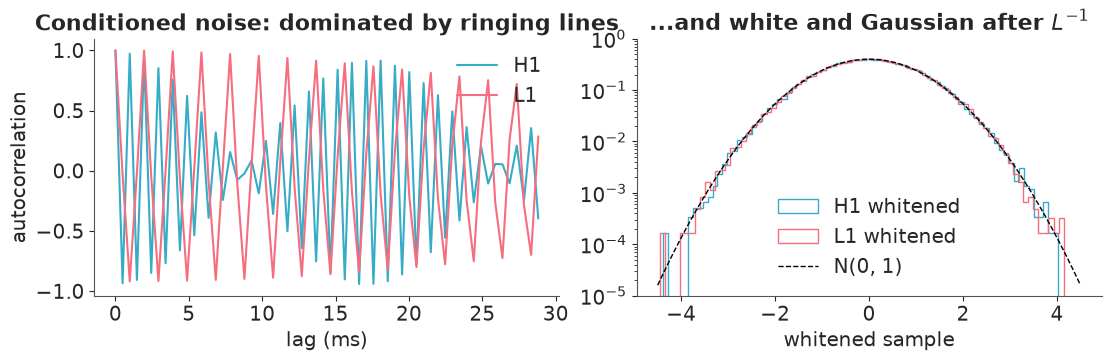

In [10]:
starts = np.arange(200, len(t_fit) - N_RING - 200, N_RING)
starts = starts[np.abs(t_fit[starts]) > 2]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
grid = np.linspace(-4.5, 4.5, 200)
for det in DETECTORS:
    raw = np.array([cond[det][s : s + N_RING] for s in starts])
    z = raw @ W_RING[det].T
    lag1 = np.mean(z[:, 1:] * z[:, :-1])
    lag1_raw = np.mean(raw[:, 1:] * raw[:, :-1]) / raw.var()
    print(f"{det}: {len(starts)} windows   mean square = {np.mean(z**2):.3f}   lag-1 correlation: "
          f"before {lag1_raw:+.3f}, after {lag1:+.3f}   excess kurtosis = {stats.kurtosis(z.ravel()):+.3f}")
    axes[0].plot(np.arange(60) / FS_FIT * 1e3, acf[det][:60] / acf[det][0], label=det)
    axes[1].hist(z.ravel(), bins=80, density=True, histtype="step", label=f"{det} whitened")
axes[0].set(xlabel="lag (ms)", ylabel="autocorrelation", title="Conditioned noise: dominated by ringing lines")
axes[0].legend()
axes[1].plot(grid, stats.norm.pdf(grid), "k--", lw=1, label="N(0, 1)")
axes[1].set(xlabel="whitened sample", yscale="log", ylim=(1e-5, 1), title="...and white and Gaussian after $L^{-1}$")
axes[1].legend();

The conditioned noise is as far from white as it gets. Once the low frequencies are
removed, about 96% of the remaining variance is in narrow lines - near 1 kHz in H1, just
below the new Nyquist frequency, which is why its neighbouring samples are
*anti*-correlated at -0.93; near 515 Hz in L1 - and lines ring for a long time. After
$L^{-1}$ all of that is gone: the lag-1 correlation is zero to three decimals, the variance
is 1, and the tails follow the Gaussian over four decades. For these 30 seconds,
"stationary and Gaussian" is a good description.

### 2.2 · The model

**Phase as quadratures.** Writing
$A\cos(\omega t - \varphi) = a_c\cos\omega t + a_s\sin\omega t$ with
$a_c = A\cos\varphi,\ a_s = A\sin\varphi$ replaces a **wrapped** angle by two unbounded
numbers. NUTS moves through a Euclidean space: it cannot step from $\varphi = 3.1$ to
$-3.1$ even though they are neighbours on the circle, so a posterior that straddles the
wrap looks bimodal to it, and at $A \to 0$ the phase is undefined (a funnel). In
quadratures the posterior is a single blob - and, given $(f, \tau)$, the template is
**linear** in $(a_c, a_s)$ with Gaussian priors, which we will exploit in Part 3.
Independent $\mathcal{N}(0, s)$ priors on the quadratures imply a uniform phase and a
Rayleigh amplitude.

**Two detectors.** Each detector gets its own quadratures. Why not "one amplitude and
phase, plus a time shift and a relative amplitude"? Because for a damped sinusoid a time
shift $\delta$ *is* a phase shift $2\pi f\delta$ and a rescaling $e^{\delta/\tau}$: the two
parameterisations describe the same family of curves, but the time-shift version has a
ridge that repeats every $1/f \approx 4$ ms. So we **align** the L1 window using the
cross-correlation shift from Part 1, keep the well-behaved parameters, and *derive* the
relative amplitude, the sign and the implied time shift afterwards (2.5).

**Start time.** The model only holds once the remnant has settled into linear ringing.
Published analyses put the peak strain at Hanford at about GPS 1126259462.423 (`T_PEAK`,
t = 23 ms here; our whitened envelope peaks 1-2 ms later, which is within the smearing of
the filters). Guided by the LIGO-Virgo testing-GR paper, where a single damped sinusoid
starts to agree with the full analysis about 3 ms after the merger, we start **3 ms after
the peak**, and treat that as a choice to be stress-tested (2.6), not a fact. Start times are
rounded up to the next sample (at most 0.5 ms).

**Priors.** $f \sim \text{Uniform}(150, 400)$ Hz: the ringdown should sit at or above the
~150-250 Hz reached at the end of the chirp in the time-frequency map.
$\tau \sim \text{LogNormal}(\log 4\text{ ms}, 0.75)$, i.e. roughly 1-17 ms: a bell that
rings for a handful of cycles. Quadratures $\sim \mathcal{N}(0, 2)$ in units of
$10^{-21}$, because the published peak strain is about 1 in those units.

In [11]:
AMP_SD = 2.0
MSUN_S = 4.925491e-6  # G * Msun / c^3 in seconds: a solar mass expressed as a time

# Berti-Cardoso-Will (2006) fits for the l = m = 2, n = 0 Kerr quasi-normal mode
F1, F2, F3 = 1.5251, -1.1568, 0.1292
Q1, Q2, Q3 = 0.7000, 1.4187, -0.4990


def ringdown_parts(t0_h1, n=N_RING):
    """Per detector: time since the first sample at or after t0, whitening matrix, whitened data, start."""
    parts = {}
    for det in DETECTORS:
        i = np.searchsorted(t_fit, t0_h1 - (DT_HL if det == "L1" else 0.0))
        parts[det] = (np.arange(n) / FS_FIT, W_RING[det], W_RING[det] @ cond[det][i : i + n], t_fit[i])
    return parts


def ringdown_model(parts, kerr_prior=False, sigma=1.0):
    with pm.Model(coords={"det": DETECTORS}) as model:
        if kerr_prior:  # section 2.7
            mass = pm.Uniform("mass", 35, 140)
            chi = pm.Uniform("chi", 0, 0.99)
            f = pm.Deterministic("f", (F1 + F2 * (1 - chi) ** F3) / (2 * np.pi * mass * MSUN_S))
            tau_ms = pm.Deterministic("tau_ms", 1e3 * (Q1 + Q2 * (1 - chi) ** Q3) / (np.pi * f))
        else:
            f = pm.Uniform("f", 150, 400)
            tau_ms = pm.LogNormal("tau_ms", np.log(4), 0.75)
        a_cos = pm.Normal("a_cos", 0, AMP_SD, dims="det")
        a_sin = pm.Normal("a_sin", 0, AMP_SD, dims="det")

        snr_sq = 0
        for k, det in enumerate(DETECTORS):
            tw, W, y, _ = parts[det]
            h = pt.exp(-tw / (tau_ms / 1e3)) * (
                a_cos[k] * pt.cos(2 * np.pi * f * tw) + a_sin[k] * pt.sin(2 * np.pi * f * tw)
            )
            h_white = pt.dot(W, h)  # the template goes through the same whitening as the data
            pm.Normal(f"y_{det}", mu=h_white, sigma=sigma, observed=y)
            snr_sq += pt.sum(h_white**2) / sigma**2

        pm.Deterministic("amp", pt.sqrt(a_cos**2 + a_sin**2), dims="det")
        pm.Deterministic("snr", pt.sqrt(snr_sq))  # network "optimal" signal-to-noise ratio of the template
    return model


T0_OFFSET = 0.003
ring_parts = ringdown_parts(T_PEAK + T0_OFFSET)
ring_model = ringdown_model(ring_parts)
ring_model

### 2.3 · Prior predictive check

The derived `snr` is $\lVert L^{-1}h\rVert$ summed over detectors: how many noise standard
deviations the template stands out by. It is the natural scale on which to ask what the
priors claim.

Sampling: [a_cos, a_sin, f, tau_ms, y_H1, y_L1]


prior SNR quantiles (5%, 50%, 95%): [ 5.5 15.2 37.6]


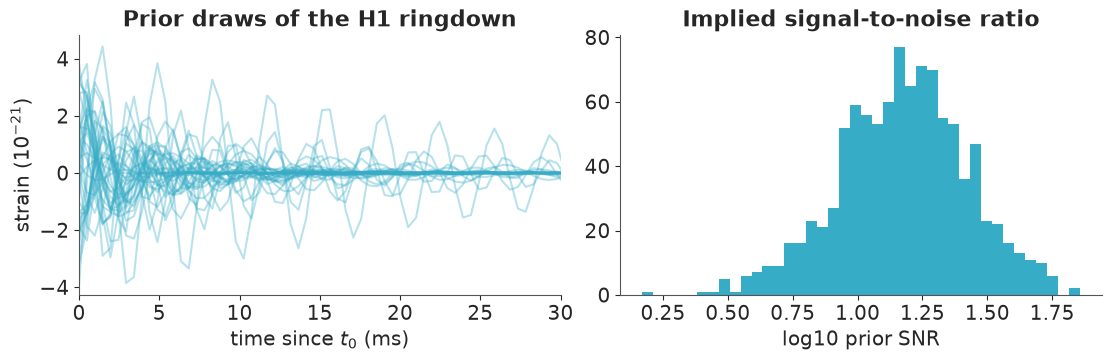

In [12]:
with ring_model:
    ring_prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)


def ringdown_np(tw, f, tau_ms, a_cos, a_sin):
    return np.exp(-tw / (tau_ms / 1e3)) * (a_cos * np.cos(2 * np.pi * f * tw) + a_sin * np.sin(2 * np.pi * f * tw))


prior = az.extract(ring_prior, group="prior", num_samples=40, random_seed=RANDOM_SEED)
tw = np.arange(N_RING) / FS_FIT

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for j in range(prior.sizes["sample"]):
    p = prior.isel(sample=j)
    axes[0].plot(tw * 1e3, ringdown_np(tw, float(p["f"]), float(p["tau_ms"]), *p["a_cos"].values[:1], *p["a_sin"].values[:1]),
                 color="C0", alpha=0.35)
axes[0].set(xlim=(0, 30), xlabel="time since $t_0$ (ms)", ylabel="strain ($10^{-21}$)", title="Prior draws of the H1 ringdown")
prior_snr = ring_prior.prior["snr"].values.ravel()
axes[1].hist(np.log10(prior_snr), bins=40)
axes[1].set(xlabel="log10 prior SNR", title="Implied signal-to-noise ratio")
print("prior SNR quantiles (5%, 50%, 95%):", np.quantile(prior_snr, [0.05, 0.5, 0.95]).round(1))

Damped wiggles of a few cycles with amplitudes of a few units: the right kind of object.
The implied SNR runs from about 5 (marginal) to about 40 (unmissable), with a median of
15. So this prior leans towards signals that are *louder* than a ringdown 3 ms after the
peak is likely to be - acceptable as a weakly-informative choice, but worth knowing; in
Part 3 we will see how much the Bayes factor cares.

### 2.4 · Fit, diagnose, check

In [13]:
with ring_model:
    ring_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(ring_idata.sample_stats["diverging"].sum()))
az.summary(ring_idata, var_names=["f", "tau_ms", "amp", "snr"], ci_kind="hdi", ci_prob=0.9, round_to=2)

NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
f,246.97,12.46,227.98,265.14,1204.04,1441.03,1.00,0.39,0.62
tau_ms,4.50,1.19,2.74,6.46,1299.43,1731.15,1.01,0.03,0.03
amp[H1],1.23,0.26,0.81,1.64,1823.29,2350.26,1.00,0.01,0.00
amp[L1],1.00,0.25,0.59,1.38,1728.81,2230.69,1.00,0.01,0.00
snr,8.03,1.02,6.47,9.77,4733.01,3289.68,1.00,0.01,0.01


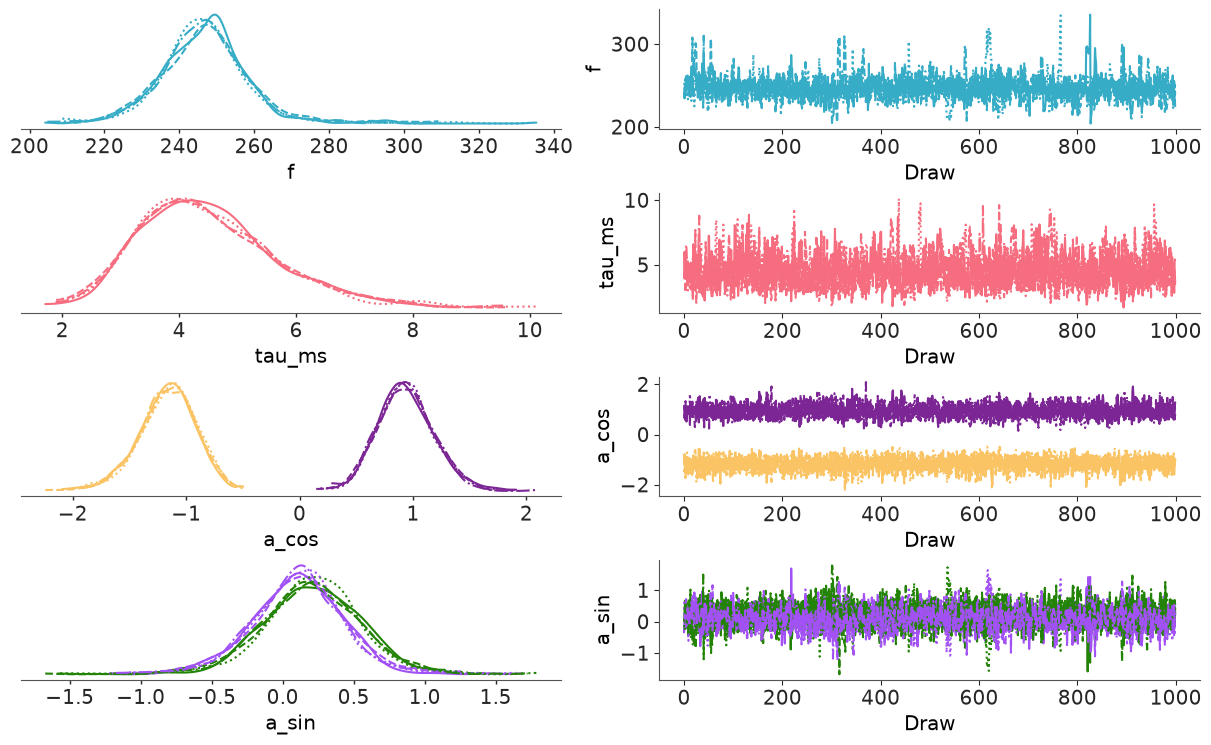

In [14]:
az.plot_trace_dist(ring_idata, var_names=["f", "tau_ms", "a_cos", "a_sin"]);

Clean: no divergences, `r_hat` at most 1.01, ESS above a thousand. Six parameters, 204 data
points and a 102 x 102 matrix product per gradient - the whole fit takes a few seconds.

For the posterior predictive check we look at the data **the way the likelihood sees
them**: whitened by $L^{-1}$. If the model is adequate, whitened data minus whitened
template should be standard normal noise.

H1: mean square of whitened data = 1.40, of whitened residuals = 1.04 (expect about 1)
L1: mean square of whitened data = 1.06, of whitened residuals = 0.84 (expect about 1)


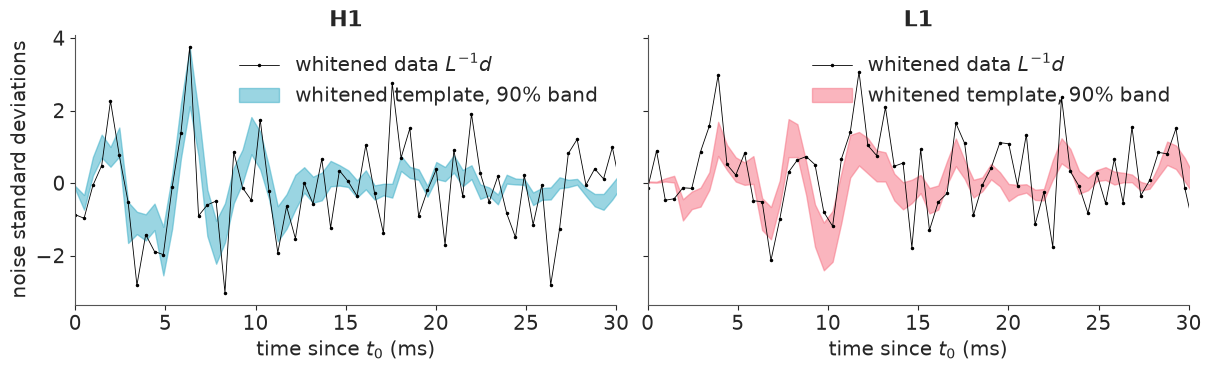

In [15]:
post = az.extract(ring_idata, num_samples=500, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for k, (ax, det) in enumerate(zip(axes, DETECTORS)):
    tw, W, y, _ = ring_parts[det]
    templates = np.array([
        W @ ringdown_np(tw, f_, tau_, ac_, as_)
        for f_, tau_, ac_, as_ in zip(post["f"].values, post["tau_ms"].values,
                                      post["a_cos"].values[k], post["a_sin"].values[k])
    ])
    lo, hi = np.quantile(templates, [0.05, 0.95], axis=0)
    ax.plot(tw * 1e3, y, "k.-", lw=0.6, ms=3, label="whitened data $L^{-1}d$")
    ax.fill_between(tw * 1e3, lo, hi, color=f"C{k}", alpha=0.5, label="whitened template, 90% band")
    ax.set(xlim=(0, 30), xlabel="time since $t_0$ (ms)", title=det)
    ax.legend(loc="upper right")
    resid = y - templates
    print(f"{det}: mean square of whitened data = {np.mean(y**2):.2f}, "
          f"of whitened residuals = {np.mean(resid**2, axis=1).mean():.2f} (expect about 1)")
axes[0].set_ylabel("noise standard deviations");

The whitened template is not a pretty damped sinusoid - $L^{-1}$ reshapes it, which is
exactly why the template must go through the same operator as the data. The first few
samples carry the signal (several standard deviations), and after subtracting the template
the residual mean square is compatible with 1 (for 102 samples it scatters by about 0.14;
in H1 it drops from 1.40 to 1.04). A ringdown starting 3 ms after the peak is
a **weak** signal: a network SNR of about 8, spread over a handful of samples.

### 2.5 · Do the two detectors tell the same story?

Each detector has its own amplitude and phase. If both see the same wave, with Livingston
inverted and ahead by $\Delta t$, then after our alignment the phases should differ by
$\pi$, and any leftover phase is a leftover time shift:
$\Delta t = \Delta t_\text{used} - (\Delta\varphi - \pi)/(2\pi f)$.

In [16]:
p = ring_idata.posterior
phase = np.arctan2(p["a_sin"], p["a_cos"])
dphi = (phase.sel(det="L1") - phase.sel(det="H1")) % (2 * np.pi)
dt_used = ring_parts["H1"][3] - ring_parts["L1"][3]
dt_implied = 1e3 * (dt_used - (dphi - np.pi) / (2 * np.pi * p["f"]))
amp_ratio = p["amp"].sel(det="L1") / p["amp"].sel(det="H1")

for label, x in [("phase difference / pi", dphi / np.pi), ("implied H1-L1 time shift (ms)", dt_implied),
                 ("amplitude ratio L1/H1", amp_ratio)]:
    q = np.quantile(x, [0.05, 0.5, 0.95])
    print(f"{label:<32} median {q[1]:.2f}   90% interval [{q[0]:.2f}, {q[2]:.2f}]")

phase difference / pi            median 1.09   90% interval [0.94, 1.25]
implied H1-L1 time shift (ms)    median 7.13   90% interval [6.82, 7.45]
amplitude ratio L1/H1            median 0.81   90% interval [0.51, 1.23]


The phase difference is compatible with $\pi$ - the sign flip; you can also see it in the
trace plot above, where `a_cos` is about -1.1 in H1 and +0.9 in L1. Read as a time shift,
the ringdown alone gives 7.1 ms with a 90% interval of 6.8-7.5 ms, overlapping both the
cross-correlation value and the published $6.9^{+0.5}_{-0.4}$ ms. Two caveats: this is the
solution *nearest* to the alignment we imposed (add any multiple of $1/f \approx 4$ ms and
the fit is identical - the interval is conditional on having picked the right cycle), and
"same wave, inverted" is only approximately true because the detectors are not exactly
anti-aligned. The amplitude ratio is compatible with 1 and poorly measured.

### 2.6 · The start time is a modelling choice - so vary it

Start too early and the data still contain the non-linear merger, which a single damped
sinusoid cannot describe (bias). Start too late and the signal has decayed into the noise
(variance). There is no objectively correct $t_0$, so we show the dependence.

In [17]:
offsets_ms = [0, 1, 3, 5, 7]
scan = {}
for off in offsets_ms:
    if off == 1e3 * T0_OFFSET:
        scan[off] = ring_idata
        continue
    with ringdown_model(ringdown_parts(T_PEAK + off / 1e3)):
        scan[off] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

rows = []
for off, idata in scan.items():
    row = {"t0 - t_peak (ms)": off}
    for v in ["f", "tau_ms", "snr"]:
        lo, med, hi = np.quantile(idata.posterior[v], [0.05, 0.5, 0.95])
        row.update({f"{v} median": med, f"{v} lo": lo, f"{v} hi": hi})
    row["max r_hat"] = float(az.summary(idata, var_names=["f", "tau_ms", "a_cos", "a_sin"])["r_hat"].max())
    row["divergences"] = int(idata.sample_stats["diverging"].sum())
    rows.append(row)
scan_table = pd.DataFrame(rows).set_index("t0 - t_peak (ms)")
scan_table.round(2)

NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


,f median,f lo,f hi,tau_ms median,tau_ms lo,tau_ms hi,snr median,snr lo,snr hi,max r_hat,divergences
t0 - t_peak (ms),,,,,,,,,,,
0,234.13,223.84,242.49,5.50,4.22,7.13,12.33,10.74,13.98,1.00,0
1,233.41,218.94,244.48,5.38,3.82,7.60,9.73,8.10,11.36,1.01,0
3,246.74,228.16,265.57,4.34,2.86,6.70,8.03,6.40,9.73,1.01,0
5,278.31,210.33,358.93,2.29,1.14,4.93,5.60,3.96,7.16,1.01,0
7,218.47,155.89,362.48,1.13,0.46,2.71,3.84,2.34,5.36,1.01,0


Kerr black hole with M = 68 Msun, chi = 0.69:  f = 252 Hz, tau = 4.10 ms


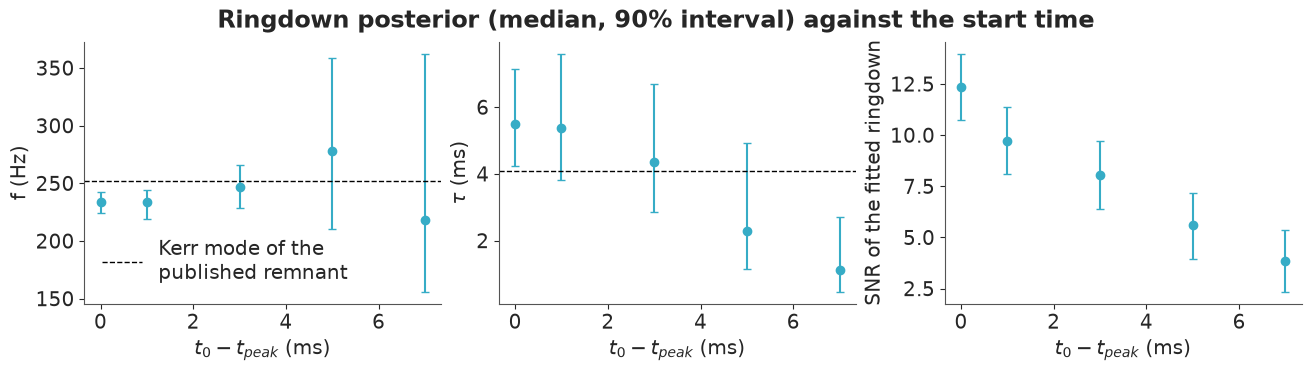

In [18]:
def kerr_qnm(mass, chi):
    """Frequency (Hz) and damping time (s) of the 220 mode of a Kerr black hole (mass in Msun, detector frame)."""
    f = (F1 + F2 * (1 - chi) ** F3) / (2 * np.pi * mass * MSUN_S)
    return f, (Q1 + Q2 * (1 - chi) ** Q3) / (np.pi * f)


f_pub, tau_pub = kerr_qnm(68.0, 0.69)
print(f"Kerr black hole with M = 68 Msun, chi = 0.69:  f = {f_pub:.0f} Hz, tau = {tau_pub * 1e3:.2f} ms")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, v, ref, label in zip(axes, ["f", "tau_ms", "snr"], [f_pub, tau_pub * 1e3, None],
                             ["f (Hz)", r"$\tau$ (ms)", "SNR of the fitted ringdown"]):
    med, lo, hi = (scan_table[f"{v} {c}"] for c in ["median", "lo", "hi"])
    ax.errorbar(scan_table.index, med, yerr=[med - lo, hi - med], fmt="o", capsize=3)
    if ref is not None:
        ax.axhline(ref, color="k", ls="--", lw=1, label="Kerr mode of the\npublished remnant")
    if v == "f":
        ax.legend(loc="lower left")
    ax.set(xlabel="$t_0 - t_{peak}$ (ms)", ylabel=label)
fig.suptitle("Ringdown posterior (median, 90% interval) against the start time");

Read the three panels together:

- **SNR** falls steadily as we start later - the signal decays with a ~4 ms time constant.
- At **0-1 ms** the posterior is narrow but sits at a lower frequency (233-234 Hz) and a
  longer damping time (about 5.5 ms) than the Kerr mode of the published remnant. Precise
  and biased: a single mode is being asked to describe the merger. (Published work argues
  that adding *overtones* repairs this; see "Try it yourself".)
- At **3 ms** the posterior is centred near 247 Hz and 4.3 ms, and comfortably contains
  the expected mode. The LIGO-Virgo testing-GR paper reports the same qualitative
  pattern: its damped-sinusoid fit becomes consistent with the full-waveform prediction
  from about 3 ms after the merger.
- By **5-7 ms** the posterior for $f$ spreads over much of its prior and $\tau$ drifts
  towards short values: there is little signal left, and what the fit finds is
  increasingly noise. Notice the `snr` panel cannot tell you that by itself - a flexible
  template always finds *something* (Part 3).

The dashed reference line was computed with the fitting formulas we meet next, so let us
do that properly.

### 2.7 · The payoff: mass and spin of the remnant

For a Kerr black hole of mass $M$ and dimensionless spin $\chi$, Berti, Cardoso & Will
(2006) give accurate fits for the dominant ($\ell = m = 2$, $n = 0$) mode:

$$2\pi f\,\frac{GM}{c^3} = f_1 + f_2(1-\chi)^{f_3}, \qquad Q \equiv \pi f\tau = q_1 + q_2(1-\chi)^{q_3}.$$

The quality factor $Q$ depends on spin only; given the spin, the frequency sets the mass.
The check above (68 $M_\odot$, $\chi = 0.69$ gives 252 Hz and 4.1 ms) is our sanity test of
the constants and units.
Inverting is one line per draw - but it is only possible when $Q > q_1 + q_2 = 2.12$
(the value at $\chi = 0$). Draws with a lower $Q$ ring down faster than *any* Kerr black
hole would, and have no mass or spin.

In [19]:
def invert_kerr(f, tau):
    quality = np.pi * f * tau
    with np.errstate(invalid="ignore"):
        chi = 1 - ((quality - Q1) / Q2) ** (1 / Q3)
        mass = (F1 + F2 * (1 - chi) ** F3) / (2 * np.pi * f * MSUN_S)
    return mass, chi


draws = az.extract(ring_idata, var_names=["f", "tau_ms"])
mass_draws, chi_draws = invert_kerr(draws["f"].values, draws["tau_ms"].values / 1e3)
physical = np.isfinite(chi_draws) & (chi_draws >= 0)
print(f"share of posterior draws with no Kerr counterpart (Q < 2.12): {1 - physical.mean():.1%}")
for label, x in [("mass (Msun, detector frame)", mass_draws[physical]), ("spin chi", chi_draws[physical])]:
    q = np.quantile(x, [0.05, 0.5, 0.95])
    print(f"{label:<30} median {q[1]:.2f}   90% interval [{q[0]:.2f}, {q[2]:.2f}]")

share of posterior draws with no Kerr counterpart (Q < 2.12): 3.7%
mass (Msun, detector frame)    median 71.49   90% interval [54.57, 87.60]
spin chi                       median 0.73   90% interval [0.26, 0.90]


A few percent of the draws are "not a Kerr black hole". That is a symptom of a prior
that was flat in $(f, \tau)$ and knew nothing about black holes. If we believe the remnant
is a Kerr black hole, the honest thing is to **put the prior where the belief is**: sample
$M$ and $\chi$ directly and compute $(f, \tau)$ from them inside the model. With a
likelihood this weak, the two priors will not give the same answer - that is the point
of doing both.

In [20]:
with ringdown_model(ring_parts, kerr_prior=True):
    kerr_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(kerr_idata.sample_stats["diverging"].sum()))
az.summary(kerr_idata, var_names=["mass", "chi", "f", "tau_ms"], ci_kind="eti", ci_prob=0.9, round_to=2)

NUTS[nutpie]: [mass, chi, a_cos, a_sin]


divergences: 0


,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mass,67.82,10.50,51.86,85.47,388.16,554.85,1.01,0.54,0.33
chi,0.59,0.22,0.16,0.89,405.35,552.07,1.01,0.01,0.01
f,245.52,12.19,226.96,265.78,1893.12,1752.33,1.00,0.29,0.33
tau_ms,4.22,1.20,2.92,6.33,390.08,552.03,1.01,0.06,0.12


No divergences and `r_hat` at 1.00-1.01, but the ESS for mass and spin is a few hundred
rather than a thousand-plus: the curved mass-spin ridge below is harder going for NUTS
than the blob in $(f, \tau)$. Adequate for the 90% intervals we quote; run longer before
quoting anything finer.

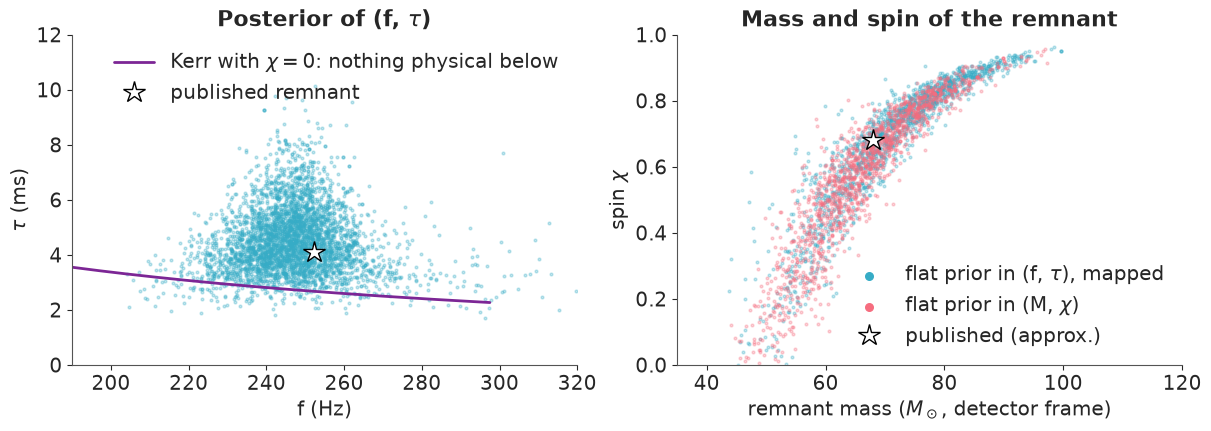

In [21]:
kerr_draws = az.extract(kerr_idata, var_names=["mass", "chi"])
sub = rng.choice(np.flatnonzero(physical), 1500, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(draws["f"].values, draws["tau_ms"].values, s=4, alpha=0.3)
f_line, tau_line = kerr_qnm(np.linspace(40, 140, 50), 0.0)
axes[0].plot(f_line, tau_line * 1e3, color="C3", lw=2, label=r"Kerr with $\chi = 0$: nothing physical below")
axes[0].plot(f_pub, tau_pub * 1e3, "w*", ms=16, mec="k", label="published remnant")
axes[0].set(xlim=(190, 320), ylim=(0, 12), xlabel="f (Hz)", ylabel=r"$\tau$ (ms)", title=r"Posterior of (f, $\tau$)")
axes[0].legend(loc="upper right")

axes[1].scatter(mass_draws[sub], chi_draws[sub], s=4, alpha=0.3)
axes[1].scatter(kerr_draws["mass"].values[:1500], kerr_draws["chi"].values[:1500], s=4, alpha=0.3)
axes[1].scatter([], [], s=30, color="C0", label=r"flat prior in (f, $\tau$), mapped")  # legible legend entries
axes[1].scatter([], [], s=30, color="C1", label=r"flat prior in (M, $\chi$)")
axes[1].plot(68, 0.68, "w*", ms=16, mec="k", label="published (approx.)")
axes[1].set(xlim=(35, 120), ylim=(0, 1), xlabel=r"remnant mass ($M_\odot$, detector frame)", ylabel=r"spin $\chi$",
            title="Mass and spin of the remnant")
axes[1].legend(loc="lower right");

From 50 milliseconds of data and a damped sinusoid: a black hole of very roughly
**70 solar masses, spinning at some large fraction of the maximum**. The published
values from the full analysis are a detector-frame mass of about 68 $M_\odot$
(62-63 $M_\odot$ in the source frame, after removing the cosmological redshift
$z \approx 0.09$ - a ringdown alone cannot do that, it only ever measures the redshifted
mass) and a spin of 0.67-0.69. Those sit well inside our posterior. But be clear about
how little that says:

- Our 90% intervals are **broad** - roughly 52-88 $M_\odot$, and a spin anywhere from
  0.15 to 0.9 depending on the prior. Almost all of the published precision comes from the
  inspiral and merger, which we threw away. Broad is the correct answer for a
  ringdown-only analysis at this SNR.
- Mass and spin are strongly **correlated** (the banana in the right panel): a heavier,
  faster-spinning hole rings at the same frequency as a lighter, slower one.
- The answer **depends on the prior**: the flat-in-$(M,\chi)$ fit prefers a lower spin
  (about 0.6) than the mapped flat-in-$(f,\tau)$ fit (about 0.7), because equal areas in
  $(f,\tau)$ are not equal areas in $(M,\chi)$ - high spins occupy a large slice of
  $\tau$. Neither is "the" answer; reporting both is more honest than reporting one.
- And it depends on $t_0$ (2.6).

### 2.8 · What would the whitening shortcut have cost?

Back to section 1.5. Suppose we had fitted the Part 1 data - FFT-whitened, band-passed, at
4096 Hz - with independent Normal errors, from the same $t_0$. To be fair to the
shortcut we whiten the template correctly: the combined whitening + band-pass filter is a
convolution, so on a window it is a matrix built from its impulse response, and the very
same PyMC model applies with a different `W`. We try two noise levels: `sigma = 1`
(the level *before* band-passing, which is what Parseval's theorem justifies) and
`sigma = 0.37` (the measured std of the band-passed noise, which is what most of us
would reach for).

In [22]:
N_SHORT = 205  # the same 50 ms, at 4096 Hz


def shortcut_parts(t0_h1):
    parts = {}
    lag_idx = np.arange(N_SHORT)[:, None] - np.arange(N_SHORT)[None, :]
    for det in DETECTORS:
        kernel = np.fft.irfft(bp_gain / np.sqrt(psd_on_grid[det] * fs / 2), n=n_samples)  # impulse response
        i = np.searchsorted(t, t0_h1 - (DT_HL if det == "L1" else 0.0))
        parts[det] = (np.arange(N_SHORT) / fs, kernel[lag_idx % n_samples], white_bp[det][i : i + N_SHORT], t[i])
    return parts


sigma_bp = np.mean([white_bp[det][quiet].std() for det in DETECTORS])
fits = {"exact: time-domain covariance": ring_idata}
for label, sigma in [("shortcut, sigma = 1", 1.0), (f"shortcut, sigma = {sigma_bp:.2f}", sigma_bp)]:
    with ringdown_model(shortcut_parts(T_PEAK + T0_OFFSET), sigma=sigma):
        fits[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

comparison = pd.concat(
    {label: az.summary(idata, var_names=["f", "tau_ms", "amp"], round_to=4)[["mean", "sd", "r_hat"]]
     for label, idata in fits.items()}
).round(2)
comparison

NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


mean     sd  r_hat
exact: time-domain covariance f        246.97  12.46   1.00
                              tau_ms     4.50   1.19   1.01
                              amp[H1]    1.23   0.26   1.00
                              amp[L1]    1.00   0.25   1.00
shortcut, sigma = 1           f        244.30  13.73   1.00
                              tau_ms     2.85   0.71   1.01
                              amp[H1]    2.00   0.44   1.00
                              amp[L1]    1.85   0.46   1.00
shortcut, sigma = 0.37        f        243.34   3.75   1.00
                              tau_ms     3.13   0.31   1.00
                              amp[H1]    1.83   0.15   1.00
                              amp[L1]    1.69   0.16   1.00

Two different failures, neatly separated:

- **`sigma = 0.37`** shrinks the posterior standard deviations by a factor of two to four
  relative to `sigma = 1` (just under 3 for the amplitudes, which scale with `sigma`).
  Nothing about the data improved; we told the model that 205 strongly correlated samples
  were independent measurements at the band-passed noise level. The rule of thumb:
  band-limited noise of bandwidth $B$ has only $2B$ independent samples per second (here
  630, not 4096), so the information is over-counted by $4096/630 \approx 6.5$ and widths
  shrink by about $\sqrt{6.5} \approx 2.5$ - the same ballpark. Overconfident by a factor
  of three is the kind of error that produces false "tensions" with general relativity.
- **`sigma = 1`** gives sensible widths, as the Parseval argument promised, but the
  answer has **moved**: a damping time under 3 ms instead of 4.5 ms, and amplitudes more
  than half as large again as in the exact fit. The likely culprit is trap 3: the acausal
  filters smear the loud merger into the first milliseconds after $t_0$, and the model
  explains that extra power with a bigger, faster-decaying ringdown. We have not proven
  that here (an injection study would), but it is the reason the ringdown literature gives
  for working in the time domain.

So the exact time-domain likelihood is not pedantry. It is also no harder to write.

## Part 3 · Is there really a signal?

A damped sinusoid with free frequency, decay, amplitude and phase will fit *something* in
any stretch of noise. Before believing Part 2 we should ask how the same analysis
behaves when there is nothing there - and we have 30 seconds of "nothing there" in the
same file.

### 3.1 · The same model on off-source data

In [23]:
off_times = [-11.0, -7.0, -3.0, 4.0, 8.0, 12.0]
rows = [{"segment": "on-source", "snr": ring_idata.posterior["snr"], "idata": ring_idata}]
for t_off in off_times:
    with ringdown_model(ringdown_parts(t_off)):
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    rows.append({"segment": f"t = {t_off:+.0f} s", "snr": idata.posterior["snr"], "idata": idata})

off_table = pd.DataFrame([
    {"segment": r["segment"],
     "snr median": float(r["snr"].median()),
     "snr 5%": float(r["snr"].quantile(0.05)), "snr 95%": float(r["snr"].quantile(0.95)),
     "amp H1 median": float(r["idata"].posterior["amp"].sel(det="H1").median()),
     "f sd (Hz)": float(r["idata"].posterior["f"].std()),
     "max r_hat": float(az.summary(r["idata"], var_names=["f", "tau_ms", "a_cos", "a_sin"])["r_hat"].max()),
     "divergences": int(r["idata"].sample_stats["diverging"].sum())}
    for r in rows
]).set_index("segment")
off_table.round(2)

NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


NUTS[nutpie]: [f, tau_ms, a_cos, a_sin]


,snr median,snr 5%,snr 95%,amp H1 median,f sd (Hz),max r_hat,divergences
segment,,,,,,,
on-source,8.03,6.40,9.73,1.21,12.46,1.01,0
t = -11 s,2.29,1.06,3.77,0.69,71.40,1.01,5
t = -7 s,2.14,1.00,3.57,0.55,80.53,1.00,1
t = -3 s,2.93,1.59,4.49,0.74,67.32,1.03,11
t = +4 s,2.69,1.34,4.14,1.02,74.84,1.00,1
t = +8 s,3.62,2.15,5.23,1.04,78.41,1.00,0
t = +12 s,2.16,0.96,3.76,0.57,76.86,1.01,3


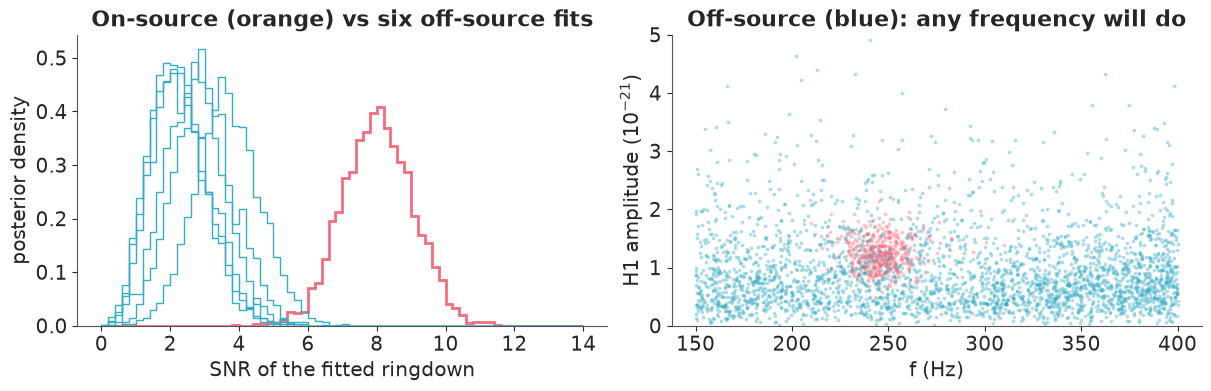

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for i, r in enumerate(rows):
    colour = "C1" if i == 0 else "C0"
    axes[0].hist(r["snr"].values.ravel(), bins=np.linspace(0, 14, 71), histtype="step", density=True,
                 color=colour, lw=2 if i == 0 else 1, label=r["segment"] if i < 2 else None)
    axes[1].scatter(r["idata"].posterior["f"].values.ravel()[::8], r["idata"].posterior["amp"].sel(det="H1").values.ravel()[::8],
                    s=3, alpha=0.3, color=colour)
axes[0].set(xlabel="SNR of the fitted ringdown", ylabel="posterior density", title="On-source (orange) vs six off-source fits")
axes[1].set(xlabel="f (Hz)", ylabel="H1 amplitude ($10^{-21}$)", ylim=(0, 5), title="Off-source (blue): any frequency will do");

On noise, the frequency posterior simply returns its prior (an sd of 67-81 Hz, against
72 Hz for Uniform(150, 400)) and the fitted SNR has a median of 2-4 - not zero, because a
norm is positive and a flexible template can always soak up a little noise. On-source the
SNR posterior sits clearly apart and the draws form one tight cluster in the right panel.
Note what does *not* discriminate: the **amplitude**. Off-source medians are 0.5-1, not far
below the on-source 1.2, because a large amplitude with a very short damping time costs
almost nothing in SNR. The question "is the amplitude zero?" is the wrong one; "does the
template explain variance?" is the right one. Several off-source fits show divergences
(up to 11 here) and an `r_hat` up to 1.03: with no signal, the posterior is the awkward
union of "small template, any frequency" and a few weak noise bumps. That is a property
of the question, not a bug to tune away.

### 3.2 · A Bayes factor that actually computes

"Signal versus noise" is a comparison between our model and the same model with all four
amplitudes set to zero, which has no free parameters at all. Bayes factors are
notoriously hard to compute, but this problem has structure: **given $(f, \tau)$, the
whitened template is linear in the four quadratures, with Gaussian priors and Gaussian
noise**. The quadratures can be integrated out in closed form (it is Bayesian linear
regression with design matrix $X = L^{-1}[e^{-t/\tau}\cos\omega t,\ e^{-t/\tau}\sin\omega t]$):

$$\log\frac{p(d \mid f,\tau)}{p(d \mid \text{noise})}
  = \tfrac12\, b^\top\!\big(G + s^{-2}I\big)^{-1} b - \tfrac12\log\det\!\big(I + s^2 G\big),
  \qquad G = X^\top X,\; b = X^\top L^{-1}d .$$

What is left is a two-dimensional integral over $(f, \tau)$, which a grid does to high
accuracy in a few seconds (most of it spent whitening the basis once). No sampler, no
tuning, no stochastic error.

In [25]:
f_grid = np.linspace(150, 400, 201)
tau_grid = np.geomspace(0.3, 50, 100)  # ms
tw = np.arange(N_RING) / FS_FIT

ff, tt = np.meshgrid(f_grid, tau_grid, indexing="ij")
decay = np.exp(-tw / (tt[..., None] / 1e3))
basis = np.stack([decay * np.cos(2 * np.pi * ff[..., None] * tw), decay * np.sin(2 * np.pi * ff[..., None] * tw)], axis=-1)
X_GRID = {det: np.einsum("ij,ftjk->ftik", W_RING[det], basis) for det in DETECTORS}  # whitened basis, every grid point
G_GRID = {det: np.einsum("ftik,ftil->ftkl", X_GRID[det], X_GRID[det]) for det in DETECTORS}

# prior mass of each grid cell: uniform in f, log-normal in tau
log_prior_grid = stats.lognorm(s=0.75, scale=4).logpdf(tau_grid) + np.log(np.gradient(tau_grid))
log_prior_grid = (log_prior_grid - logsumexp(log_prior_grid))[None, :] - np.log(len(f_grid))


def log_bf_surface(whitened, amp_sd=AMP_SD):
    """log p(d | f, tau) / p(d | noise) on the grid, amplitudes marginalised. `whitened`: {det: L^-1 d}."""
    out = 0.0
    for det in DETECTORS:
        b = np.einsum("ftik,i->ftk", X_GRID[det], whitened[det])
        A = G_GRID[det] + np.eye(2) / amp_sd**2
        out = out + 0.5 * np.einsum("ftk,ftk->ft", b, np.linalg.solve(A, b[..., None])[..., 0])
        out = out - 0.5 * np.log(np.linalg.det(np.eye(2) + amp_sd**2 * G_GRID[det]))
    return out


def log_bayes_factor(whitened, amp_sd=AMP_SD):
    return logsumexp(log_bf_surface(whitened, amp_sd) + log_prior_grid)


on_source = {det: ring_parts[det][2] for det in DETECTORS}
log_bf_on = log_bayes_factor(on_source)
print(f"on-source: ln BF (signal : noise) = {log_bf_on:.1f}   ->   BF ~ {np.exp(log_bf_on):.1e}")

on-source: ln BF (signal : noise) = 19.7   ->   BF ~ 3.5e+08


**Cross-check 1: the grid reproduces NUTS.** The same grid gives the exact marginal
posterior of $(f, \tau)$, which should match the PyMC fit from 2.4.

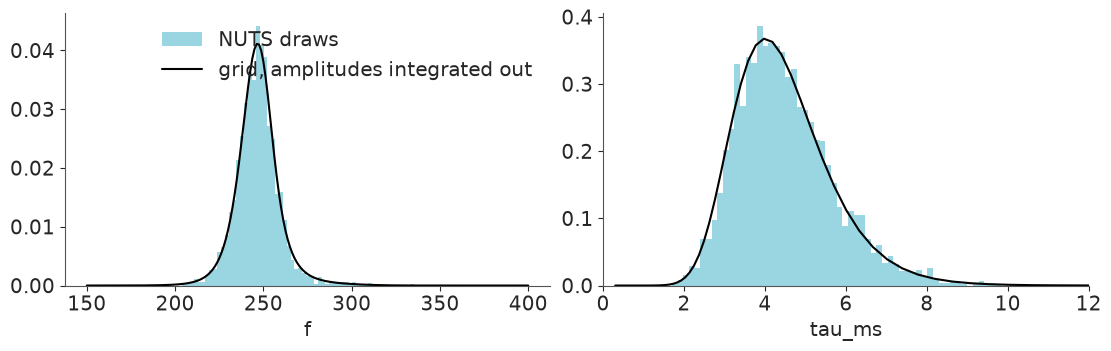

In [26]:
log_post = log_bf_surface(on_source) + log_prior_grid
post_grid = np.exp(log_post - logsumexp(log_post))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, v, g, marginal in [(axes[0], "f", f_grid, post_grid.sum(axis=1)), (axes[1], "tau_ms", tau_grid, post_grid.sum(axis=0))]:
    ax.hist(ring_idata.posterior[v].values.ravel(), bins=60, density=True, alpha=0.5, label="NUTS draws")
    ax.plot(g, marginal / np.gradient(g), "k", label="grid, amplitudes integrated out")
    ax.set(xlabel=v)
axes[1].set_xlim(0, 12)
axes[0].legend(loc="upper right");

**Cross-check 2: Sequential Monte Carlo.** `pm.sample_smc` tempers from the prior to the
posterior and estimates the marginal likelihood as a by-product. It runs fine in PyMC 6;
the estimate lives in `sample_stats["log_marginal_likelihood"]` as an object array with one
entry per tempering stage, of which only the last is the final estimate. To turn it into a
Bayes factor, subtract the log-likelihood of the noise model, which is just the standard
normal log-density of the whitened data.

In [27]:
with ring_model:
    # SMC runs one worker PROCESS per core, each with its own copy of the model: cores=2 keeps memory in check
    smc_idata = pm.sample_smc(2000, chains=4, cores=2, random_seed=RANDOM_SEED, progressbar=False)

log_z_noise = sum(stats.norm.logpdf(on_source[det]).sum() for det in DETECTORS)
log_z_smc = np.array([
    np.asarray(chain, dtype=float)[np.isfinite(np.asarray(chain, dtype=float))][-1]
    for chain in smc_idata.sample_stats["log_marginal_likelihood"].values
])
print("ln BF from SMC, per chain:", (log_z_smc - log_z_noise).round(2), f"   grid: {log_bf_on:.2f}")

Initializing SMC sampler...


Sampling 4 chains in 2 jobs


ln BF from SMC, per chain: [19.57 19.74 19.59 19.74]    grid: 19.68


The four SMC chains agree with one another and with the grid to within about 0.2. Two
independent methods, one number: $\ln \text{BF} \approx 19.7$, odds of a few hundred
million to one. For a generic model you would have only SMC (or bridge sampling, or nested
sampling); the lesson of the grid is to look for **conditionally linear-Gaussian
structure** first, because integrating parameters out analytically beats any sampler.

**But what is a Bayes factor of $10^8$ worth?** It compares *our two models*: "Gaussian
noise plus a damped sinusoid" versus "Gaussian noise". Real detectors glitch, and a glitch
is neither. The empirical answer is to compute the same statistic where we know there is
no astrophysical signal, and see what the noise can do: a **background distribution**.
Because the grid is fast, we can afford every non-overlapping off-source window.

237 off-source windows: ln BF from -6.9 to -0.7, 0 of them favour a signal


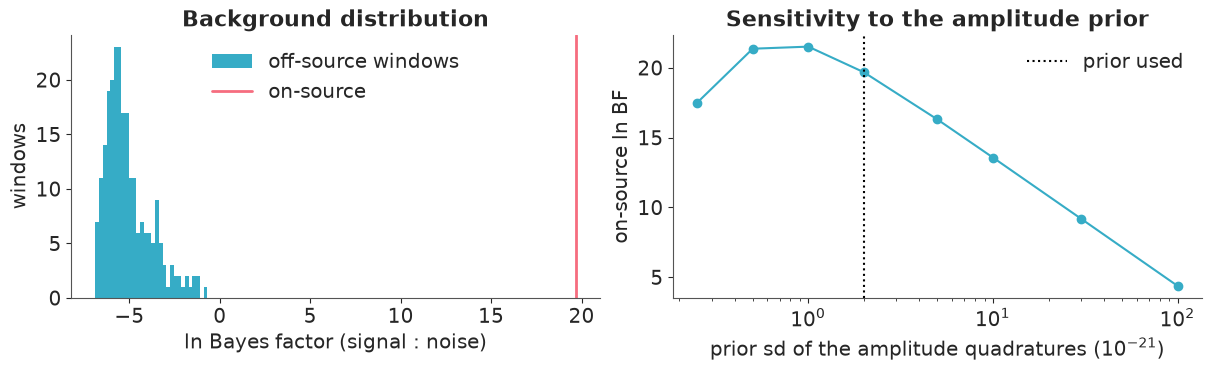

In [28]:
bg_times = np.arange(-13, 15, 0.11)
bg_times = bg_times[np.abs(bg_times) > 1]


def whitened_at(t_start, extra=None):
    out = {}
    for k, det in enumerate(DETECTORS):
        i = np.searchsorted(t_fit, t_start - (DT_HL if det == "L1" else 0.0))
        d = cond[det][i : i + N_RING] + (0 if extra is None else extra[k])
        out[det] = W_RING[det] @ d
    return out


log_bf_bg = np.array([log_bayes_factor(whitened_at(ts)) for ts in bg_times])
print(f"{len(bg_times)} off-source windows: ln BF from {log_bf_bg.min():.1f} to {log_bf_bg.max():.1f}, "
      f"{(log_bf_bg > 0).sum()} of them favour a signal")

amp_sds = np.array([0.25, 0.5, 1, 2, 5, 10, 30, 100])
log_bf_vs_prior = [log_bayes_factor(on_source, s) for s in amp_sds]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(log_bf_bg, bins=30, label="off-source windows")
axes[0].axvline(log_bf_on, color="C1", lw=2, label="on-source")
axes[0].set(xlabel="ln Bayes factor (signal : noise)", ylabel="windows", title="Background distribution")
axes[0].legend()
axes[1].semilogx(amp_sds, log_bf_vs_prior, "o-")
axes[1].axvline(AMP_SD, color="k", ls=":", label="prior used")
axes[1].set(xlabel="prior sd of the amplitude quadratures ($10^{-21}$)", ylabel="on-source ln BF",
            title="Sensitivity to the amplitude prior")
axes[1].legend();

Every one of the off-source windows has a **negative** log Bayes factor: when there is
nothing there, the evidence (mildly) prefers the simpler model - Occam's razor working as
advertised. The on-source value is far outside anything the noise produced. With a couple
of hundred windows that supports a false-alarm probability below about 1 in 200 for this
statistic and no more; LIGO's "less than one in 200,000 years" comes from time-sliding
weeks of data from the two sites against each other, which 32 seconds cannot imitate.

The right panel is the standard health warning. The Bayes factor depends on the prior
width: make the amplitude prior absurdly wide and the signal model is penalised for all
the loud signals it predicted and did not see (roughly $-4\ln s$ for four amplitudes).
Here the conclusion survives any remotely sensible choice, but the *number* is only
meaningful together with the prior that produced it.

### 3.3 · Is the likelihood calibrated on real noise? (SBC, for free)

The exact grid posterior makes **simulation-based calibration** cheap: draw parameters
from the prior, add the corresponding ringdown to a *real* off-source noise window,
compute the posterior, and record where the truth falls in it. If the whole pipeline -
noise model, whitening, priors - is right, those posterior CDF values are uniform. Unlike
a test on simulated Gaussian noise, this one can fail if the real noise is not what our
likelihood assumes.

f       KS test against uniform: p = 0.52   coverage of the central 90% interval: 0.92
tau_ms  KS test against uniform: p = 0.91   coverage of the central 90% interval: 0.89


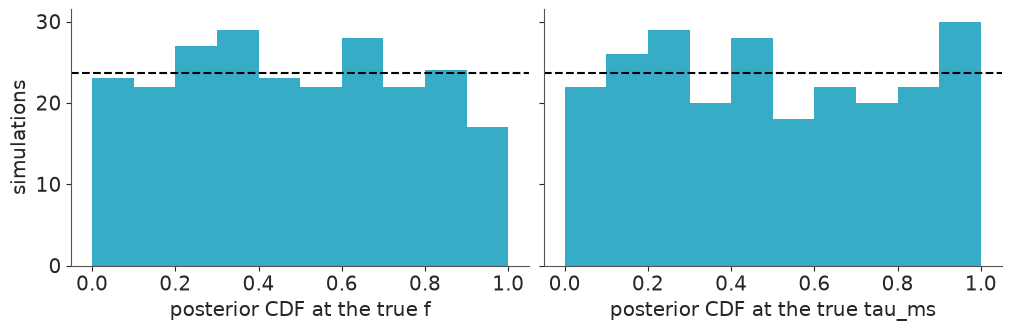

In [29]:
sbc_rng = np.random.default_rng(RANDOM_SEED)
pit = {"f": [], "tau_ms": []}
for ts in bg_times:
    f_true = sbc_rng.uniform(150, 400)
    tau_true = np.exp(sbc_rng.normal(np.log(4), 0.75))
    quad = sbc_rng.normal(0, AMP_SD, size=(2, 2))
    injected = [ringdown_np(tw, f_true, tau_true, *quad[k]) for k in range(2)]
    lp = log_bf_surface(whitened_at(ts, extra=injected)) + log_prior_grid
    pg = np.exp(lp - logsumexp(lp))
    marg_f, marg_tau = pg.sum(axis=1), pg.sum(axis=0)
    # posterior CDF at the truth, interpolated between grid points
    pit["f"].append(np.interp(f_true, f_grid, np.cumsum(marg_f) - 0.5 * marg_f))
    pit["tau_ms"].append(np.interp(np.log(tau_true), np.log(tau_grid), np.cumsum(marg_tau) - 0.5 * marg_tau))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (v, values) in zip(axes, pit.items()):
    values = np.array(values)
    ax.hist(values, bins=10, range=(0, 1))
    ax.axhline(len(values) / 10, color="k", ls="--")
    ax.set(xlabel=f"posterior CDF at the true {v}")
    print(f"{v:<7} KS test against uniform: p = {stats.kstest(values, 'uniform').pvalue:.2f}   "
          f"coverage of the central 90% interval: {np.mean((values > 0.05) & (values < 0.95)):.2f}")
axes[0].set_ylabel("simulations");

Histograms compatible with flat, and 90% intervals that cover the truth 92% and 89% of the
time, with 237 simulations (so a binomial standard error of 2 points) on real detector
noise. Do not read more into it than that: for the loudest prior draws the posterior is
narrower than a grid cell, which limits this check to a few points of coverage (repeating
it with other seeds gives 88-94%). Within that resolution the *machinery* - noise
covariance, whitening, marginalisation, priors - is calibrated. It says nothing about
whether a single damped sinusoid is the right model for what GW150914 did 3 ms after its
peak - that was section 2.6.

### 3.4 · How detection is actually done: the matched filter

LIGO's search pipelines do not run MCMC on every second of data. They slide templates
across the data and compute, for every arrival time at once (one FFT),

$$\rho(t) = \frac{|\langle d, h_t\rangle|}{\sqrt{\langle h, h\rangle}}, \qquad
  \langle a, b\rangle = 4\,\mathrm{Re}\!\int_0^\infty \frac{\tilde a(f)\,\tilde b^*(f)}{S(f)}\,df .$$

That inner product is the Whittle likelihood again: for fixed template shape, $\rho^2/2$ is
the log-likelihood ratio maximised over amplitude, and taking the modulus of the complex
filter output maximises over phase. **The matched filter is the maximum-likelihood cousin
of the marginalisation we just did** - the same two quadratures, maximised instead of
integrated. In Gaussian noise $\rho$ of a few is typical and 5 is already rare.

We use two templates: our ringdown (posterior medians from 2.4), and the inspiral chirp of
Part 4 at leading order, for a small bank of chirp masses.

H1: chirp template peak SNR 17.0 at t = 26.5 ms (loudest elsewhere 4.3);   ringdown template peak SNR 9.2 at t = 25.0 ms (elsewhere 4.4)
L1: chirp template peak SNR 11.0 at t = 18.9 ms (loudest elsewhere 4.8);   ringdown template peak SNR 8.3 at t = 17.5 ms (elsewhere 4.6)
network SNR of the best chirp template: 20.2


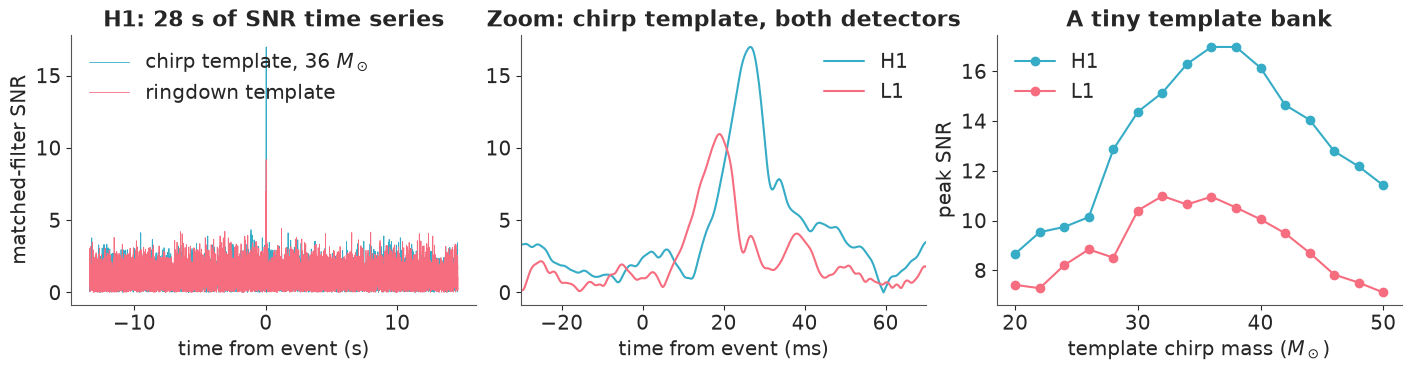

In [30]:
def matched_filter(x, template, psd_grid, f_lo=30.0, f_hi=500.0):
    """|SNR| time series; `template` is sampled like `x`, with its reference time at index 0 (wrapping around)."""
    df = freqs[1]
    band = (freqs >= f_lo) & (freqs <= f_hi)
    x_f = np.fft.rfft(x * taper) * dt
    h_f = np.fft.rfft(template) * dt
    integrand = np.zeros(n_samples, dtype=complex)  # positive frequencies only -> complex SNR (both phases)
    integrand[: len(freqs)] = np.where(band, x_f * np.conj(h_f) / psd_grid, 0)
    z = 4 * np.fft.ifft(integrand) * n_samples * df
    sigma_sq = 4 * np.sum(np.where(band, np.abs(h_f) ** 2 / psd_grid, 0)) * df
    return np.abs(z) / np.sqrt(sigma_sq)


def newtonian_chirp_template(chirp_mass, f_min=25.0, stop=0.004):
    """Leading-order inspiral ending at index 0 (i.e. the SNR is reported at the coalescence time)."""
    to_merger = (n_samples - np.arange(n_samples)) * dt
    m_sec = chirp_mass * MSUN_S
    f_gw = (5 / (256 * to_merger)) ** 0.375 * m_sec**-0.625 / np.pi
    phase = -2 * (to_merger / (5 * m_sec)) ** 0.625
    return np.where((f_gw > f_min) & (to_merger > stop), to_merger**-0.25 * np.cos(phase), 0.0)


t_since_start = np.arange(n_samples) * dt
f_med, tau_med = float(ring_idata.posterior["f"].median()), float(ring_idata.posterior["tau_ms"].median())
ring_template = np.exp(-t_since_start / (tau_med / 1e3)) * np.cos(2 * np.pi * f_med * t_since_start)

inner = (t > t[0] + 2) & (t < t[-1] - 2)  # stay away from the tapered edges
bank = np.arange(20, 52, 2)
bank_snr = {det: np.array([matched_filter(strain[det], newtonian_chirp_template(mc), psd_on_grid[det])[inner].max() for mc in bank])
            for det in DETECTORS}
best_mc = bank[np.argmax(np.sqrt(bank_snr["H1"] ** 2 + bank_snr["L1"] ** 2))]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for det in DETECTORS:
    snr_chirp = matched_filter(strain[det], newtonian_chirp_template(best_mc), psd_on_grid[det])
    snr_ring = matched_filter(strain[det], ring_template, psd_on_grid[det])
    far = inner & (np.abs(t - T_PEAK) > 0.5)
    print(f"{det}: chirp template peak SNR {snr_chirp[inner].max():.1f} at t = {1e3 * t[inner][snr_chirp[inner].argmax()]:.1f} ms "
          f"(loudest elsewhere {snr_chirp[far].max():.1f});   ringdown template peak SNR {snr_ring[inner].max():.1f} "
          f"at t = {1e3 * t[inner][snr_ring[inner].argmax()]:.1f} ms (elsewhere {snr_ring[far].max():.1f})")
    if det == "H1":
        axes[0].plot(t[inner], snr_chirp[inner], lw=0.6, label=f"chirp template, {best_mc} $M_\\odot$")
        axes[0].plot(t[inner], snr_ring[inner], lw=0.6, label="ringdown template")
    axes[1].plot(t[inner] * 1e3, snr_chirp[inner], label=det)
    axes[2].plot(bank, bank_snr[det], "o-", label=det)
axes[0].set(xlabel="time from event (s)", ylabel="matched-filter SNR", title="H1: 28 s of SNR time series")
axes[0].legend(loc="upper left")
axes[1].set(xlim=(-30, 70), xlabel="time from event (ms)", title="Zoom: chirp template, both detectors")
axes[1].legend()
axes[2].set(xlabel=r"template chirp mass ($M_\odot$)", ylabel="peak SNR", title="A tiny template bank")
axes[2].legend()
print(f"network SNR of the best chirp template: {np.sqrt(bank_snr['H1'].max() ** 2 + bank_snr['L1'].max() ** 2):.1f}")

One spike in 28 seconds, in both detectors, at times 7-8 ms apart - against a background
that never exceeds 5. The ringdown template alone reaches an SNR of 8-9
(it also rings on the merger, so this is higher than the SNR of the post-$t_0$ fit in
Part 2); the chirp template collects the whole inspiral and does far better. Our network
SNR of about 20 falls short of the published 24 because a leading-order inspiral that
stops 4 ms before merger is a cruder template than the ones LIGO uses.

Note where the little template bank peaks: at a chirp mass of 36-38 $M_\odot$, not the
published value of about 30. Hold that thought.

## Part 4 (stretch) · The inspiral chirp

Before they merge, two masses in orbit lose energy to gravitational waves, so the orbit
shrinks and speeds up. At leading ("Newtonian quadrupole") order the gravitational-wave
frequency and phase depend on the masses only through the **chirp mass**
$\mathcal{M} = (m_1 m_2)^{3/5}/(m_1+m_2)^{1/5}$:

$$f(t) = \frac{1}{\pi}\left(\frac{5}{256\,(t_c - t)}\right)^{3/8}\left(\frac{G\mathcal{M}}{c^3}\right)^{-5/8},
\qquad \Phi(t) = -2\left(\frac{t_c - t}{5\,G\mathcal{M}/c^3}\right)^{5/8},
\qquad h(t) \propto f^{2/3}\cos(\Phi(t) + \varphi_c) \propto (t_c-t)^{-1/4}\cos(\dots)$$

where $t_c$ is the (formal) coalescence time at which the frequency diverges. We fit the
185 ms that end 15 ms before the peak - where the approximation is least bad - with exactly
the machinery of Part 2: a 379-sample window per detector, the full noise covariance, L1
aligned by the Part 1 shift. Priors: $\mathcal{M} \sim \text{Uniform}(15, 60)\,M_\odot$ and
$t_c \sim \mathcal{N}(t_\text{peak}, 5\text{ ms})$, because the frequency visibly stops
rising at the peak.

### 4.1 · The obvious parameterisation, and how it fails

Amplitude and phase at coalescence per detector - what you would write down first.

In [31]:
T_CHIRP = (T_PEAK - 0.200, T_PEAK - 0.015)

chirp_parts = {}
for det in DETECTORS:
    shift = DT_HL if det == "L1" else 0.0
    i0, i1 = np.searchsorted(t_fit, [T_CHIRP[0] - shift, T_CHIRP[1] - shift])
    W = whitener(det, i1 - i0)
    chirp_parts[det] = (t_fit[i0:i1] + shift, W, W @ cond[det][i0:i1])  # times on the H1 clock
print({det: len(v[0]) for det, v in chirp_parts.items()}, "samples per detector")


def chirp_phase_amp(chirp_mass, tc, times, xp=pt):
    to_merger = xp.maximum(tc - times, 1e-4)
    return -2 * (to_merger / (5 * chirp_mass * MSUN_S)) ** 0.625, (to_merger / 0.1) ** -0.25


with pm.Model(coords={"det": DETECTORS}) as chirp_naive:
    chirp_mass = pm.Uniform("chirp_mass", 15, 60)
    tc_ms = pm.Normal("tc_ms", 0, 5)  # coalescence time relative to T_PEAK, in ms
    A = pm.HalfNormal("A", AMP_SD, dims="det")  # amplitude 0.1 s before coalescence
    phi_c = pm.Uniform("phi_c", -np.pi, np.pi, dims="det")
    for k, det in enumerate(DETECTORS):
        times, W, y = chirp_parts[det]
        phase, growth = chirp_phase_amp(chirp_mass, T_PEAK + tc_ms / 1e3, times)
        pm.Normal(f"y_{det}", mu=pt.dot(W, A[k] * growth * pt.cos(phase + phi_c[k])), sigma=1, observed=y)
    naive_idata = pm.sample(random_seed=RANDOM_SEED)

print("divergences:", int(naive_idata.sample_stats["diverging"].sum()))
az.summary(naive_idata, round_to=2)

NUTS[nutpie]: [chirp_mass, tc_ms, A, phi_c]


{'H1': 379, 'L1': 379} samples per detector


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tc_ms,4.30,4.55,-2.07,11.62,5.41,10.93,2.07,2.11,0.75
chirp_mass,37.19,1.93,34.14,40.08,5.62,11.60,1.95,0.85,0.27
A[H1],0.56,0.07,0.46,0.68,34.19,70.02,1.09,0.01,0.00
A[L1],0.36,0.07,0.26,0.47,1566.87,2200.81,1.01,0.00,0.00
phi_c[H1],0.47,1.74,-2.76,2.85,5.91,11.49,1.84,0.78,0.34
phi_c[L1],-0.88,1.57,-2.99,1.94,5.77,11.24,1.89,0.68,0.28


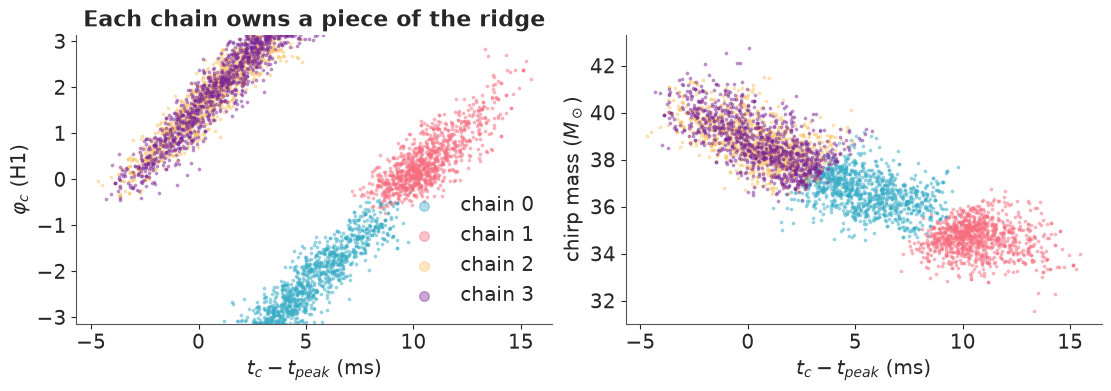

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for c in naive_idata.posterior.chain.values:
    pc = naive_idata.posterior.sel(chain=c)
    axes[0].scatter(pc["tc_ms"], pc["phi_c"].sel(det="H1"), s=3, alpha=0.4, label=f"chain {c}")
    axes[1].scatter(pc["tc_ms"], pc["chirp_mass"], s=3, alpha=0.4)
axes[0].set(xlabel="$t_c - t_{peak}$ (ms)", ylabel=r"$\varphi_c$ (H1)", ylim=(-np.pi, np.pi), title="Each chain owns a piece of the ridge")
axes[0].legend(markerscale=4, loc="lower right")
axes[1].set(xlabel="$t_c - t_{peak}$ (ms)", ylabel=r"chirp mass ($M_\odot$)");

An `r_hat` of about 2 and an ESS in single digits for $t_c$ and the chirp mass: the chains
disagree, and **no divergence warned us**. The left panel shows why. The phase at
coalescence is an extrapolation of the phase in the window, so it is almost perfectly
correlated with $t_c$: moving $t_c$ by several milliseconds winds $\varphi_c$ through a
full turn. The posterior is one long diagonal ridge wrapped around a cylinder - where it
leaves the plot at $+\pi$ it re-enters at $-\pi$ - but to NUTS the $\pm\pi$ edges of the
Uniform prior are walls. With two detectors, each with its own wrapped phase, the ridge
is chopped into several pieces; each chain explores the piece it started in, and so sees
only part of the $t_c$-$\mathcal{M}$ range (right panel). This is the $(t_c, \varphi)$
multimodality every gravitational-wave sampler has to deal with; more tuning or a higher
`target_accept` will not fix it.

### 4.2 · The fix: integrate the nuisance parameters out

The trouble lives entirely in amplitude and phase, which we do not care about - and, as
in 3.2, in quadrature form the template is *linear* in them. So marginalise them
analytically. What remains is a two-parameter posterior for $(\mathcal{M}, t_c)$, which
we can both map exactly on a grid and hand to NUTS via `pm.Potential`. (Production codes
do the same thing: phase, and often time and distance, are marginalised analytically
before the sampler sees the problem.)

In [33]:
def chirp_basis(chirp_mass, tc, times, pn_order=0, eta=0.25):
    """Whitened-ready quadrature basis. pn_order > 0 adds post-Newtonian phase corrections (section 4.3)."""
    to_merger = np.maximum(tc - times, 1e-4)
    total_mass = chirp_mass * MSUN_S / eta**0.6
    theta = eta * to_merger / (5 * total_mass)
    series = theta**0.625
    if pn_order >= 1:
        series = series + (3715 / 8064 + 55 / 96 * eta) * theta**0.375
    if pn_order >= 1.5:
        series = series - 0.75 * np.pi * theta**0.25
    phase = -2 / eta * series
    growth = (to_merger / 0.1) ** -0.25
    return np.stack([growth * np.cos(phase), growth * np.sin(phase)], axis=1)


def chirp_log_bf_grid(mc_grid, tc_grid_ms, pn_order=0):
    out = np.zeros((len(mc_grid), len(tc_grid_ms)))
    for i, mc in enumerate(mc_grid):
        for j, tc in enumerate(tc_grid_ms):
            for det in DETECTORS:
                times, W, y = chirp_parts[det]
                X = W @ chirp_basis(mc, T_PEAK + tc / 1e3, times, pn_order)
                G, b = X.T @ X, X.T @ y
                out[i, j] += 0.5 * b @ np.linalg.solve(G + np.eye(2) / AMP_SD**2, b)
                out[i, j] -= 0.5 * np.log(np.linalg.det(np.eye(2) + AMP_SD**2 * G))
    return out


mc_grid = np.linspace(15, 60, 91)
tc_grid = np.linspace(-14, 25, 79)
chirp_surface = chirp_log_bf_grid(mc_grid, tc_grid)
print(f"maximum ln BF on the grid: {chirp_surface.max():.1f}")

maximum ln BF on the grid: 47.9


In [34]:
with pm.Model() as chirp_marginal:
    chirp_mass = pm.Uniform("chirp_mass", 15, 60)
    tc_ms = pm.Normal("tc_ms", 0, 5)
    log_like = 0
    for det in DETECTORS:
        times, W, y = chirp_parts[det]
        phase, growth = chirp_phase_amp(chirp_mass, T_PEAK + tc_ms / 1e3, times)
        x_c, x_s = pt.dot(W, growth * pt.cos(phase)), pt.dot(W, growth * pt.sin(phase))
        # 2 x 2 linear algebra written out: A = X'X + I/s^2, b = X'y
        a11, a22, a12 = pt.sum(x_c**2) + AMP_SD**-2, pt.sum(x_s**2) + AMP_SD**-2, pt.sum(x_c * x_s)
        b1, b2 = pt.sum(x_c * y), pt.sum(x_s * y)
        det_a = a11 * a22 - a12**2
        log_like += 0.5 * (a22 * b1**2 - 2 * a12 * b1 * b2 + a11 * b2**2) / det_a - 0.5 * pt.log(det_a * AMP_SD**4)
    pm.Potential("marginal_loglike", log_like)
    # start where the matched filter of 3.4 pointed, as real pipelines do
    chirp_idata = pm.sample(random_seed=RANDOM_SEED, initvals={"chirp_mass": float(best_mc), "tc_ms": 0.0})

print("divergences:", int(chirp_idata.sample_stats["diverging"].sum()))
az.summary(chirp_idata, ci_kind="eti", ci_prob=0.9, round_to=2)

NUTS[nutpie]: [chirp_mass, tc_ms]


divergences: 0


,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tc_ms,2.81,3.65,-2.86,8.88,859.86,861.88,1.0,0.12,0.10
chirp_mass,37.82,1.65,35.15,40.61,832.51,834.34,1.0,0.06,0.04


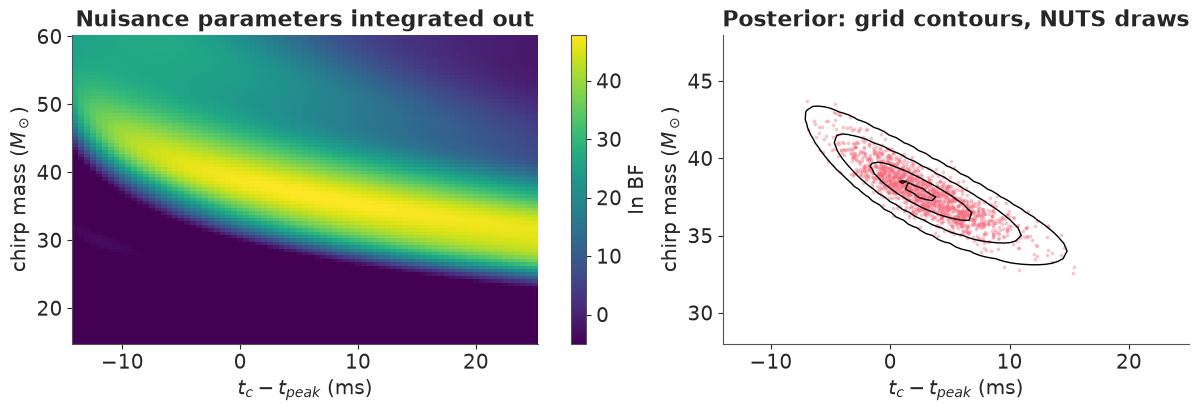

In [35]:
log_prior_chirp = stats.norm(0, 5).logpdf(tc_grid)[None, :]
chirp_post = np.exp(chirp_surface + log_prior_chirp - (chirp_surface + log_prior_chirp).max())
cd = az.extract(chirp_idata, num_samples=1500, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mesh = axes[0].pcolormesh(tc_grid, mc_grid, chirp_surface, vmin=-5, shading="auto", cmap="viridis")
axes[0].grid(False)
fig.colorbar(mesh, ax=axes[0], label="ln BF")
axes[0].set(xlabel="$t_c - t_{peak}$ (ms)", ylabel=r"chirp mass ($M_\odot$)", title="Nuisance parameters integrated out")
axes[1].contour(tc_grid, mc_grid, chirp_post, levels=[0.01, 0.1, 0.5, 0.9], colors="k", linewidths=1)
axes[1].scatter(cd["tc_ms"], cd["chirp_mass"], s=3, alpha=0.3, color="C1")
axes[1].set(xlabel="$t_c - t_{peak}$ (ms)", ylabel=r"chirp mass ($M_\odot$)", ylim=(28, 48),
            title="Posterior: grid contours, NUTS draws");

With the nuisance parameters gone the broken ridge is gone: the marginal likelihood is a
single smooth, curved ridge (a later coalescence time trades against a lower chirp mass),
NUTS samples it without complaint, and the draws sit on the exact grid contours. One more
honest detail: below the ridge the surface is a flat plateau with no gradient, and a chain
initialised there can sit on it for the whole run. That is why we passed `initvals` from
the matched-filter peak - which is precisely how real parameter estimation is seeded by
the search pipelines.

### 4.3 · The error the posterior cannot see

So: a chirp mass of about $38 \pm 2\,M_\odot$, tidy diagnostics, agreement between grid,
NUTS and the matched-filter bank. The published detector-frame value is about
30-31 $M_\odot$. **We are off by four of our own standard deviations.**

The posterior is a statement about the parameters *given the model*, and the model is the
leading term of an expansion in $v/c$ - applied to two roughly 30 $M_\odot$ black holes
in their last few orbits, moving at a third to a half of the speed of light. The next
terms of the post-Newtonian series (for the phase, in the "TaylorT3" form, with
$\Theta = \eta (t_c-t)/(5GM/c^3)$, total mass $M$ and symmetric mass ratio $\eta$) are

$$\Phi = -\frac{2}{\eta}\left[\Theta^{5/8} + \left(\tfrac{3715}{8064} + \tfrac{55}{96}\eta\right)\Theta^{3/8}
        - \tfrac{3\pi}{4}\,\Theta^{1/4} + \dots\right].$$

Fixing equal masses ($\eta = 1/4$) keeps the parameter count unchanged, and the grid makes
the experiment cheap:

In [36]:
rows = []
mc_wide = np.linspace(20, 60, 81)
for order, label in [(0, "Newtonian (0PN)"), (1, "+ 1PN"), (1.5, "+ 1PN + 1.5PN")]:
    surf = chirp_surface if order == 0 else chirp_log_bf_grid(mc_wide, tc_grid, order)
    grid_mc = mc_grid if order == 0 else mc_wide
    weights = np.exp(surf + log_prior_chirp - (surf + log_prior_chirp).max()).sum(axis=1)
    weights /= weights.sum()
    mean = np.sum(grid_mc * weights)
    rows.append({"phase model": label, "chirp mass mean": mean,
                 "sd": np.sqrt(np.sum((grid_mc - mean) ** 2 * weights)), "best ln BF": surf.max()})
pd.DataFrame(rows).set_index("phase model").round(1)

,chirp mass mean,sd,best ln BF
phase model,,,
Newtonian (0PN),37.8,1.7,47.9
+ 1PN,51.6,2.5,48.0
+ 1PN + 1.5PN,27.1,1.1,45.9


Three truncations of the same series fit the data **equally well** (the best log Bayes
factors are within about two units) and give chirp masses of roughly 38, 52 and 27
$M_\odot$, each with a confident-looking error bar of 1-3. The series is alternating and
converges slowly this close to merger; the published value lies between the rungs. The
statistical uncertainty is the small part of the error budget here, and
nothing in any single fit - not `r_hat`, not the residuals, not the Bayes factor - can
tell you so. Only varying the model can. This is why the LIGO-Virgo analyses use waveform
families calibrated against numerical solutions of Einstein's equations, run at least two
independent families, and report the difference as a systematic.

It is the same lesson as the golf putts in C01, at a rather different distance scale:
a narrow posterior is not evidence that the model is right.

## What to take away

- **Coloured noise** is handled by whitening - but whiten the template with the same
  operator, do not re-scale band-passed noise and pretend the samples are independent, and
  prefer the exact time-domain covariance when the model has a sharp edge in time.
- **Reparameterise before you tune**: quadratures instead of amplitude-phase; physical
  parameters (mass, spin) when the prior belief is physical.
- **Linear-Gaussian sub-structure is gold**: integrate it out. It gave us an exact
  posterior to check NUTS against, a Bayes factor without a sampler, a background
  distribution, SBC in seconds, and the cure for a multimodal sampler.
- **Validate on noise and on injections** drawn from the prior into real noise.
- **Vary what you assumed** - the start time, the prior, the waveform order. The largest
  uncertainties in this notebook were never inside a single posterior.

### Try it yourself

1. **Add an overtone.** Give the ringdown a second damped sinusoid (the $n = 1$ overtone)
   with its own quadratures, start at $t_0 = t_\text{peak}$, and use `kerr_prior=True`-style
   parameters so both modes share one mass and spin. Berti-Cardoso-Will coefficients for
   the 221 mode: $f_{1,2,3} = (1.3673, -1.0260, 0.1628)$ and
   $q_{1,2,3} = (0.1000, 0.5436, -0.4731)$ (check them against the paper's tables before you
   trust them - at $\chi = 0.69$ they should give a damping time of about 1.4 ms).
   Does the bias at $t_0 = t_\text{peak}$ in section 2.6 go away? How does the grid
   evidence change (you now have eight linear parameters per $(M, \chi)$ point)?
2. **Do it in the frequency domain.** Implement the Whittle likelihood for the *chirp* of
   Part 4 (whose window has no sharp physical edge if you taper it): FFT the tapered
   template with `pytensor.tensor.fft.rfft` or a JAX function brought in with
   `pytensor.wrap_jax`, and compare the posterior with the time-domain one. Where do they
   differ, and why?
3. **Let the chirp measure the time shift.** Unlike a damped sinusoid, a chirp changes
   frequency, so a time shift is *not* a phase shift. Add the H1-L1 delay as a parameter of
   the marginalised chirp model (shift the L1 time axis inside the model) with a
   Uniform(-10, 10) ms prior. Is the posterior unimodal? How does it compare with 6.9 ms?

And when you are done: register the strain files of another event from gwosc.org in
`data.py` and point the notebook at them. GW190521 is almost all ringdown, GW170817 is
almost all inspiral - see which of the conclusions above survive.

### Data credit and references

This research has made use of data obtained from the **Gravitational Wave Open Science
Center** (gwosc.org), a service of the LIGO Scientific Collaboration, the Virgo
Collaboration and KAGRA. See R. Abbott et al., "Open data from the first and second
observing runs of Advanced LIGO and Advanced Virgo", *SoftwareX* 13 (2021) 100658.

- B. P. Abbott et al., "Observation of gravitational waves from a binary black hole
  merger", *Phys. Rev. Lett.* 116, 061102 (2016) - the detection, and the published values
  quoted above (with later updates in the GWTC-1 catalogue).
- B. P. Abbott et al., "Tests of general relativity with GW150914", *Phys. Rev. Lett.* 116,
  221101 (2016) - the damped-sinusoid fit against start time.
- E. Berti, V. Cardoso and C. M. Will, *Phys. Rev. D* 73, 064030 (2006) - the quasi-normal
  mode fitting formulas.
- M. Isi and W. M. Farr, "Analyzing black-hole ringdowns", arXiv:2107.05609 - the
  time-domain likelihood used in Part 2; M. Isi et al., *Phys. Rev. Lett.* 123, 111102
  (2019) for overtones.